# Neural Network Taxi Demand Prediction -- Pooled Model

**Same pooled architecture, panel, features, baseline, and evaluation methodology as
[03.01_prediction_svm_CA_4h.ipynb](03.01_prediction_svm_CA_4h.ipynb) (SVM), with a feedforward
neural network in place of `LinearSVR`.**

- Predicts taxi pickup demand (trip counts) per spatial unit per 4h time window.
- One pooled model trained on all spatial units at once, spatial identity as a feature (one-hot
  dummies) -- same as `03.01`, not a model per unit.
- **Identical feature set, panel, profile baseline, and skill-score methodology as `03.01`** --
  see that notebook for the full reasoning (log-scale target, why pooled, validation strategy).
  Only what differs because the model is a neural network (preprocessing details, training,
  hyperparameter tuning) is new here.
- **Course constraint**: same as `03.01` -- no lagged/autoregressive demand features.

**Notebook structure** (mirrors `03.01`):
1. Data loading (1) & panel construction (2) & features (3)
2. Profile baseline (4)
3. Shallow NN -- pooled feedforward network, one hidden layer, feature importance (5)
4. NN architecture & hyperparameter search (6)
5. Results -- model comparison, per-area performance (7)
6. Shortfalls & honest limitations (8)
7. Outlook: 1-hour resolution & census tract level (9)

## Validation Strategy

Same as `03.01`: chronological holdout (train 2024-01-01 to 2025-12-31, test 2026-01-01 to
2026-05-31), a complete zero-filled grid, and the profile baseline as the reference every model
is judged against.

- **One addition, needed only because the model is a neural network**: early stopping needs its
  own held-out slice. `train` is split into `nn_fit`/`nn_es` by **whole days** (~80/20), not by
  random rows: at any given timestamp the 77 areas share identical weather/time features and
  differ only by their static area dummy, so a row-random split would leak near-identical rows
  across the split. `nn_es` never receives a gradient update; `test` is touched only for final
  evaluation.
- **Early stopping and model selection use the same demand-weighted error metrics as the
  headline results** (not generic log-space MSE): a candidate is stopped on the epoch that
  minimizes **count-space demand-weighted RMSE** on `nn_es`, and the reported Deep NN is the
  config with the best **demand-weighted skill** on `test` -- the same skill score `03.01` uses
  to pick its SVM entry.
- **The reported model is refit on the full training set** for the selected number of epochs
  (`fit_fixed_epochs`), so the NN entry is not handicapped by the 80% fit split -- `03.01`'s SVM
  fits on all of `train`.
- **Two headline metrics**, reported together for every model, identical definitions to `03.01`:
  - **Skill score**: `1 - MAE_model / MAE_baseline`, per unit -- demand-weighted (headline) and
    unweighted median (secondary, spatial-coverage guard rail).
  - **Weighted RMSE**: pooled RMSE with each row weighted by its unit's train-period mean
    demand -- an absolute number directly comparable against `03.01`'s SVM entry.
- Plain pooled R2/MAE/RMSE are a sanity check only, same caveat as `03.01` (demand varies ~1000x
  across units, so these are dominated by the busiest ones).


In [1]:
import time
import pathlib
import json

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import contextily as ctx
import holidays

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

TAXI_DATA_PATH       = "../../data/chicago_taxi_2024_2026_clean.parquet"
WEATHER_DATA_PATH    = "../../data/chicago_weather_2024_2026_hourly.csv"
COMMUNITY_AREAS_PATH = "../../data/community_areas_chicago.geojson"

# Data range covered by the cleaned parquet (June 2026+ excluded: portal reporting lag)
DATA_START    = pd.Timestamp("2024-01-01")
DATA_END_EXCL = pd.Timestamp("2026-06-01")

# Chronological split: train 2024-2025 (two full years), test Jan-May 2026 -- identical to 03.01
TRAIN_END = pd.Timestamp("2026-01-01")

# Evaluation week for baseline comparison
EVAL_WEEK_START = pd.Timestamp("2026-03-02")
EVAL_WEEK_END   = EVAL_WEEK_START + pd.Timedelta(days=7)

FREQ = "4h"  # community-area resolution at 4h windows -- same as 03.01
WEATHER_COLS = ["temperature_2m", "precipitation", "snowfall", "wind_speed_10m", "cloud_cover"]

ALL_AREAS = np.arange(1, 78)  # official community areas 1..77 -- ALL of them, no threshold (same as 03.01)

# expm1(709) overflows float64; clip the log-scale prediction first so an unstable model gets a
# very bad but finite score instead of crashing.
LOG_PRED_CAP = 20

# Chart colors (validated palette: sequential blue, diverging blue<->red) -- same as 03.01
SEQUENTIAL_BLUE = "#256abf"
DIVERGING_CMAP = LinearSegmentedColormap.from_list("diverging_blue_red", ["#e34948", "#f0efec", "#2a78d6"])
CATEGORICAL_COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
# Reproducibility on GPU: without these, cuDNN picks nondeterministic kernels and
# single-run skill comparisons (and the day-block bootstrap below) can drift between runs.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

NN_MAX_EPOCHS = 200  # upper bound; early stopping (see training machinery below) almost always stops well before this
NN_PATIENCE   = 8    # epochs without early-stopping-slice improvement before stopping
N_BOOT        = 500  # day-block bootstrap resamples for the skill confidence interval

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")
print(f"Using device: {device}")

print(f"train: {DATA_START.date()} to {TRAIN_END.date()}  "
      f"test: {TRAIN_END.date()} to {DATA_END_EXCL.date()}")

Using device: cpu
train: 2024-01-01 to 2026-01-01  test: 2026-01-01 to 2026-06-01


## 1. Data Loading

Identical to `03.01` -- combined 2024-2026 taxi parquet (see `00_data_loading`) + hourly
weather. Only pickup community area and trip timestamp needed for demand aggregation.

In [2]:
taxi = pd.read_parquet(TAXI_DATA_PATH, columns=["trip_start_timestamp", "pickup_community_area"])
n_raw = len(taxi)
taxi = taxi[taxi["pickup_community_area"].notna()].copy()
taxi["pickup_community_area"] = taxi["pickup_community_area"].astype(int)
print(f"Trips with pickup CA: {len(taxi):,} of {n_raw:,} ({len(taxi)/n_raw*100:.1f}%)")

weather = pd.read_csv(WEATHER_DATA_PATH)
weather["datetime"] = pd.to_datetime(weather["datetime"])
weather = weather[["datetime"] + WEATHER_COLS]
print(f"Weather rows: {len(weather):,}")

Trips with pickup CA: 14,201,846 of 14,465,650 (98.2%)
Weather rows: 21,168


## 2. Building the Pooled Demand Panel

Identical construction to `03.01`:
- Complete zero-filled area x window grid, all 77 areas (no demand threshold).
- Time features include a **second harmonic** for hour and day-of-week (captures the bimodal
  morning + evening rush pattern a single harmonic can't).
- Spatial identity: **community-area fixed effects** (one-hot dummies).

In [3]:
# US federal holidays (incl. observed dates), computed for every year the data covers --
# avoids maintaining a hand-picked date list that silently goes stale outside 2024-2026.
US_HOLIDAYS = pd.DatetimeIndex(sorted(
    holidays.US(years=range(DATA_START.year, DATA_END_EXCL.year + 1))
))

window = taxi["trip_start_timestamp"].dt.floor(FREQ).rename("timestamp")
counts = taxi.groupby(["pickup_community_area", window]).size().rename("count")

all_windows = pd.date_range(DATA_START, DATA_END_EXCL, freq=FREQ, inclusive="left")
grid = pd.MultiIndex.from_product([ALL_AREAS, all_windows], names=["community_area", "timestamp"])
panel = counts.reindex(grid, fill_value=0).reset_index()

w = weather.copy()
w["timestamp"] = w["datetime"].dt.floor(FREQ)
w_agg = w.groupby("timestamp")[WEATHER_COLS].mean().reset_index()
panel = panel.merge(w_agg, on="timestamp", how="left")

panel["hour"]        = panel["timestamp"].dt.hour
panel["day_of_week"] = panel["timestamp"].dt.dayofweek
panel["month"]       = panel["timestamp"].dt.month

panel["hour_sin"]         = np.sin(2 * np.pi * panel["hour"] / 24)
panel["hour_cos"]         = np.cos(2 * np.pi * panel["hour"] / 24)
panel["hour_sin2"]        = np.sin(4 * np.pi * panel["hour"] / 24)   # 2nd harmonic (captures bimodal rush pattern)
panel["hour_cos2"]        = np.cos(4 * np.pi * panel["hour"] / 24)
panel["day_of_week_sin"]  = np.sin(2 * np.pi * panel["day_of_week"] / 7)
panel["day_of_week_cos"]  = np.cos(2 * np.pi * panel["day_of_week"] / 7)
panel["day_of_week_sin2"] = np.sin(4 * np.pi * panel["day_of_week"] / 7)
panel["day_of_week_cos2"] = np.cos(4 * np.pi * panel["day_of_week"] / 7)
panel["month_sin"]        = np.sin(2 * np.pi * panel["month"] / 12)
panel["month_cos"]        = np.cos(2 * np.pi * panel["month"] / 12)
panel["is_weekend"]       = (panel["day_of_week"] >= 5).astype(int)
panel["is_holiday"]       = panel["timestamp"].dt.date.isin(US_HOLIDAYS.date).astype(int)

# Community-area fixed effects (spatial identity) -- one-hot, same as 03.01. A learned
# embedding would be the more "neural" choice, but one-hot keeps the input feature set (and
# therefore the comparison against 03.01) identical; see Shortfalls (Section 8) for this
# trade-off.
dummies = pd.get_dummies(panel["community_area"], prefix="area", drop_first=True).astype(float)
DUMMY_COLS = list(dummies.columns)
panel = pd.concat([panel, dummies], axis=1)

panel = panel.sort_values(["community_area", "timestamp"]).reset_index(drop=True)
print(f"{FREQ}: {len(panel):,} rows ({panel['community_area'].nunique()} areas x "
      f"{panel['timestamp'].nunique():,} windows), {len(DUMMY_COLS)} area dummies, "
      f"zero-demand windows: {(panel['count']==0).mean()*100:.1f}%")

4h: 407,484 rows (77 areas x 5,292 windows), 76 area dummies, zero-demand windows: 18.9%


### 2.1 Why a Log-Scale Target

Same reasoning as `03.01`: raw demand is heavily right-skewed (many low/zero windows, a long
tail of high-demand ones; median demand per area ranges from ~0 to 550+ per window -- three
orders of magnitude). `log1p(count)` is used as the regression target throughout (predictions
back-transformed via clipped `expm1`), so squared-error loss isn't dominated by a handful of
huge values -- this matters for a neural network's MSE training loss exactly as much as it does
for SVM's.

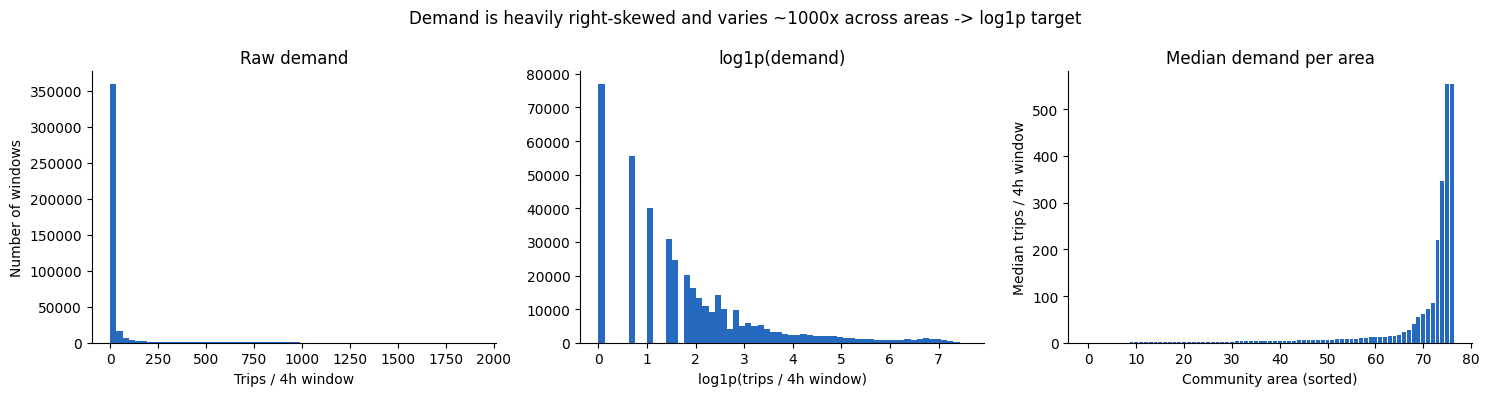

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(panel["count"], bins=60, color=SEQUENTIAL_BLUE)
axes[0].set_title("Raw demand")
axes[0].set_xlabel("Trips / 4h window")
axes[0].set_ylabel("Number of windows")

axes[1].hist(np.log1p(panel["count"]), bins=60, color=SEQUENTIAL_BLUE)
axes[1].set_title("log1p(demand)")
axes[1].set_xlabel("log1p(trips / 4h window)")

area_median_sorted = panel.groupby("community_area")["count"].median().sort_values()
axes[2].bar(range(len(area_median_sorted)), area_median_sorted.to_numpy(), color=SEQUENTIAL_BLUE, width=0.8)
axes[2].set_title("Median demand per area")
axes[2].set_xlabel("Community area (sorted)")
axes[2].set_ylabel("Median trips / 4h window")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.suptitle("Demand is heavily right-skewed and varies ~1000x across areas -> log1p target")
plt.tight_layout()
plt.show()

## 3. Feature Set & Shared Helpers

- Same 17 exogenous time/weather features + 76 community-area dummies as `03.01` -- identical
  `FEATURE_COLS`/`DUMMY_COLS`, so the two notebooks' models see exactly the same inputs.
- `ColumnTransformer` scales only the continuous features, not the dummies -- neural networks
  are less scale-sensitive than kernel SVR, but standardizing helps gradient descent converge,
  and keeping this identical to `03.01` avoids conflating a preprocessing difference with a
  model-family difference.
- Evaluation helpers (`metrics`, `weighted_rmse`, `predict_counts`, `per_area_results`,
  `skill_vs_baseline`, `weighted_skill_vs_baseline`, `relative_mae`, `print_pooled_results`) are
  copied verbatim from `03.01` -- they only assume `model.predict(X)`, so the neural network
  just needs to expose that interface (`TorchRegressor` in Section 5 does this).

In [5]:
FEATURE_COLS = [
    "temperature_2m", "precipitation", "snowfall", "wind_speed_10m", "cloud_cover",
    "hour_sin", "hour_cos", "hour_sin2", "hour_cos2",
    "day_of_week_sin", "day_of_week_cos", "day_of_week_sin2", "day_of_week_cos2",
    "month_sin", "month_cos", "is_weekend", "is_holiday",
]
ALL_COLS = FEATURE_COLS + DUMMY_COLS

preprocess = ColumnTransformer([
    ("scale", StandardScaler(), FEATURE_COLS),
    ("area_dummies", "passthrough", DUMMY_COLS),
])

train = panel[panel["timestamp"] < TRAIN_END].reset_index(drop=True)
test  = panel[panel["timestamp"] >= TRAIN_END].reset_index(drop=True)
y_true = test["count"].to_numpy(dtype=float)
print(f"train={len(train):,} rows   test={len(test):,} rows")


def metrics(y_true, y_pred):
    return {
        "r2":   round(r2_score(y_true, y_pred), 4),
        "mae":  round(mean_absolute_error(y_true, y_pred), 2),
        "rmse": round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 2),
    }


# Train-period mean demand per area -- same convention as 03.01, so weighted_rmse is directly
# comparable across the two notebooks.
UNIT_WEIGHT = train.groupby("community_area")["count"].mean()
TEST_UNIT_WEIGHTS = test["community_area"].map(UNIT_WEIGHT).fillna(UNIT_WEIGHT.mean()).to_numpy()


def weighted_rmse(y_true, y_pred, weights):
    """Pooled RMSE with each row weighted by its area's train-period mean demand, so errors
    in high-volume areas count more."""
    return float(np.sqrt(np.average((np.asarray(y_true) - np.asarray(y_pred)) ** 2, weights=weights)))


def predict_counts(model, X):
    """Back-transform log-scale predictions to counts, clipped at 0 (and capped pre-expm1
    so an unstable model's prediction can't overflow to inf)."""
    y_log = np.clip(model.predict(X), -LOG_PRED_CAP, LOG_PRED_CAP)
    return np.clip(np.expm1(y_log), 0, None)


def per_area_results(test_df, y_pred, group_col="community_area"):
    """One row per spatial unit: MAE/R2/RMSE of the pooled model's predictions for that unit."""
    tmp = pd.DataFrame({
        group_col: test_df[group_col].to_numpy(),
        "y_true": test_df["count"].to_numpy(dtype=float),
        "y_pred": y_pred,
    })
    rows = [
        {group_col: g, **metrics(g_df["y_true"], g_df["y_pred"])}
        for g, g_df in tmp.groupby(group_col)
    ]
    return pd.DataFrame(rows)


def skill_vs_baseline(results_df, baseline_df=None, group_col="community_area"):
    """Per-unit skill score: 1 - MAE_model / MAE_baseline -- comparable across units of
    different scale."""
    if baseline_df is None:
        baseline_df = baseline_results
    base = baseline_df[[group_col, "mae"]].rename(columns={"mae": "mae_base"})
    merged = results_df.merge(base, on=group_col)
    return (1 - merged["mae"] / merged["mae_base"]).rename("skill")


AREA_MEDIAN_DEMAND = panel.groupby("community_area")["count"].median().rename("median_demand")


def weighted_skill_vs_baseline(results_df, baseline_df=None, median_demand=None, group_col="community_area"):
    """Demand-weighted mean skill: each unit's skill weighted by its own median demand -- the
    headline metric (fleet is deployed mostly to high-demand areas)."""
    if median_demand is None:
        median_demand = AREA_MEDIAN_DEMAND
    skill = skill_vs_baseline(results_df, baseline_df=baseline_df, group_col=group_col)
    weights = results_df[[group_col]].merge(
        median_demand, left_on=group_col, right_index=True
    )["median_demand"].to_numpy()
    return float(np.average(skill.to_numpy(), weights=weights))


def relative_mae(results_df, median_demand=None, group_col="community_area"):
    """MAE normalized by each unit's own median demand (+1) -- an absolute, baseline-free
    error scale, complementary to skill."""
    if median_demand is None:
        median_demand = AREA_MEDIAN_DEMAND
    demand = results_df[[group_col]].merge(
        median_demand, left_on=group_col, right_index=True
    )["median_demand"].to_numpy()
    return pd.Series(results_df["mae"].to_numpy() / (demand + 1), index=results_df.index, name="relative_mae")


def print_pooled_results(label, pooled_metrics, per_area_df, baseline_df=None, median_demand=None,
                          group_col="community_area", weighted_rmse_value=None):
    w_skill = weighted_skill_vs_baseline(
        per_area_df, baseline_df=baseline_df, median_demand=median_demand, group_col=group_col,
    )
    print(label)
    print(f"  Pooled       : R2={pooled_metrics['r2']:.3f}  MAE={pooled_metrics['mae']:.2f}  "
          f"RMSE={pooled_metrics['rmse']:.2f}  (sanity check only)")
    if weighted_rmse_value is not None:
        print(f"  Weighted RMSE: {weighted_rmse_value:.2f}  (headline)")
    print(f"  Skill        : demand-weighted (headline)={w_skill:+.3f}  "
          f"unweighted median={per_area_df['skill'].median():+.3f}  "
          f"median R2={per_area_df['r2'].median():.3f}  "
          f"(areas with negative skill: {(per_area_df['skill']<0).sum()} of {len(per_area_df)})")

train=337,722 rows   test=69,762 rows


### 3.1 Feature Correlations

Sanity check before modeling, identical to `03.01`: no pair of the 17 continuous features is
near-collinear (hour/day-of-week sin-cos pairs are orthogonal by construction).

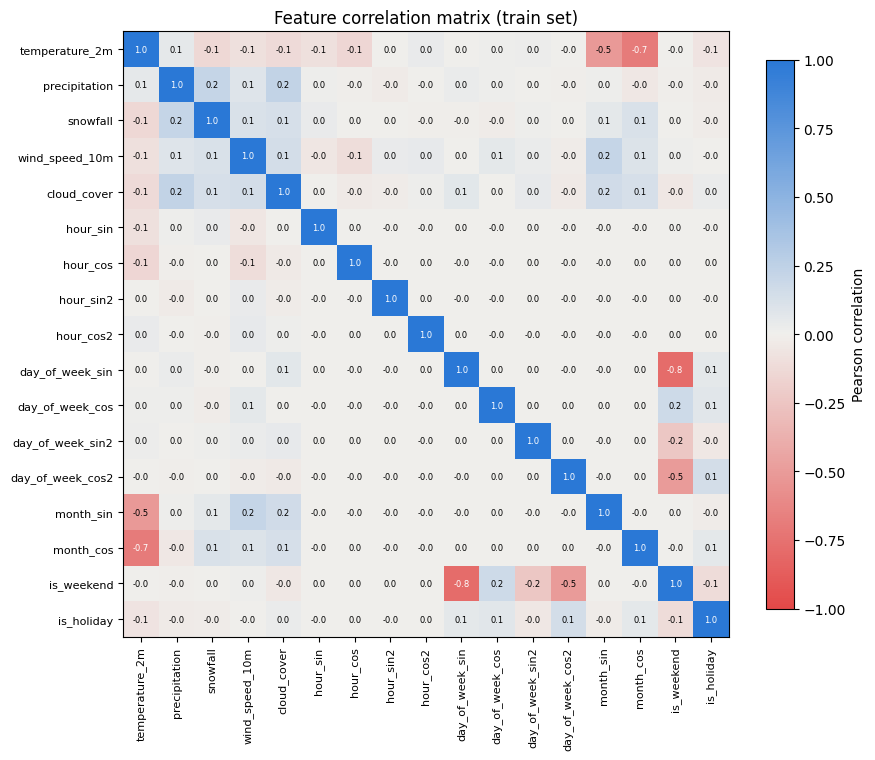

In [6]:
corr = train[FEATURE_COLS].corr()
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap=DIVERGING_CMAP, vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURE_COLS)))
ax.set_yticks(range(len(FEATURE_COLS)))
ax.set_xticklabels(FEATURE_COLS, rotation=90, fontsize=8)
ax.set_yticklabels(FEATURE_COLS, fontsize=8)
for i in range(len(FEATURE_COLS)):
    for j in range(len(FEATURE_COLS)):
        val = corr.iloc[i, j]
        ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=6,
                color="white" if abs(val) > 0.6 else "black")
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson correlation")
ax.set_title("Feature correlation matrix (train set)")
plt.tight_layout()
plt.show()

## 4. Profile Baseline

Identical to `03.01`: train-set mean demand per (hour, weekday, month), computed per area --
every area gets its own baseline/skill reference, no exclusion.

Profile baseline, all 77 areas (1s)
  Pooled  : R2=0.933  MAE=9.53  RMSE=37.31  Weighted RMSE=139.02
  Per area: median R2=0.208  median MAE=2.13  median RMSE=2.80  (areas with R2<0: 21 of 77)


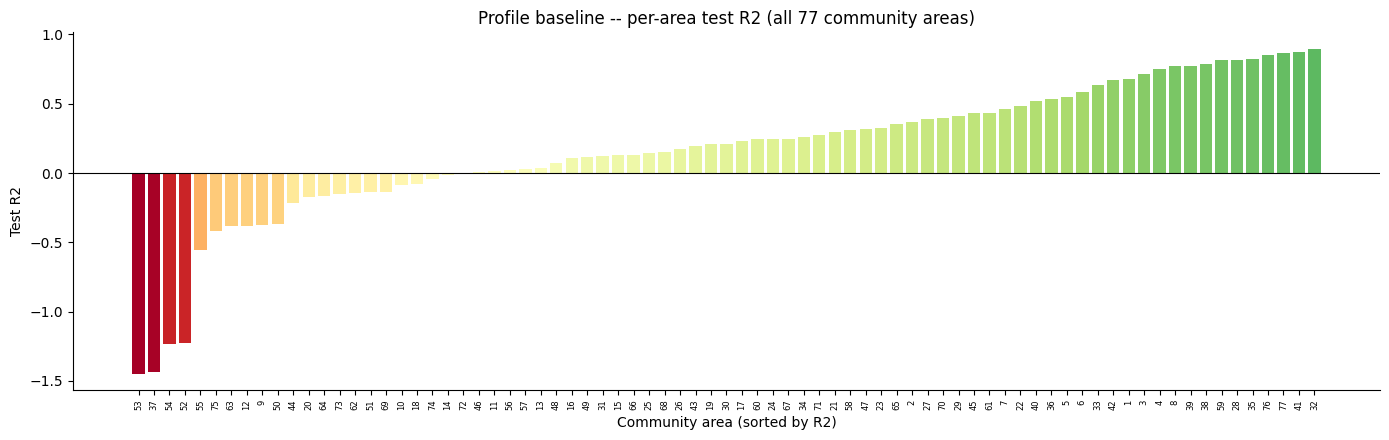

In [7]:
def profile_baseline(panel, groups, group_col="community_area"):
    results = []
    y_true_all, y_pred_all = [], []
    for g in groups:
        df_g = panel[panel[group_col] == g]
        tr = df_g[df_g["timestamp"] < TRAIN_END]
        te = df_g[df_g["timestamp"] >= TRAIN_END]
        profile = tr.groupby(["hour", "day_of_week", "month"])["count"].mean()
        fallback = tr["count"].mean()
        keys = pd.MultiIndex.from_arrays([te["hour"], te["day_of_week"], te["month"]])
        y_pred = profile.reindex(keys).fillna(fallback).to_numpy()
        y_true_ = te["count"].to_numpy(dtype=float)
        results.append({
            group_col: g,
            "median_demand": float(df_g["count"].median()),
            **metrics(y_true_, y_pred),
        })
        y_true_all.append(y_true_)
        y_pred_all.append(y_pred)
    per_group_df = pd.DataFrame(results)
    y_true_concat, y_pred_concat = np.concatenate(y_true_all), np.concatenate(y_pred_all)
    pooled = metrics(y_true_concat, y_pred_concat)
    return per_group_df, pooled, y_true_concat, y_pred_concat


t0 = time.time()
baseline_results, pm_baseline, baseline_y_true, baseline_y_pred = profile_baseline(panel, ALL_AREAS)
baseline_results["community_area"] = baseline_results["community_area"].astype(int)
baseline_results["relative_mae"] = baseline_results["mae"] / (baseline_results["median_demand"] + 1)
fit_time_base = time.time() - t0

print(f"Profile baseline, all 77 areas ({fit_time_base:.0f}s)")
print(f"  Pooled  : R2={pm_baseline['r2']:.3f}  MAE={pm_baseline['mae']:.2f}  RMSE={pm_baseline['rmse']:.2f}  "
      f"Weighted RMSE={weighted_rmse(y_true, baseline_y_pred, TEST_UNIT_WEIGHTS):.2f}")
print(f"  Per area: median R2={baseline_results['r2'].median():.3f}  "
      f"median MAE={baseline_results['mae'].median():.2f}  "
      f"median RMSE={baseline_results['rmse'].median():.2f}  "
      f"(areas with R2<0: {(baseline_results['r2']<0).sum()} of {len(baseline_results)})")

plot_df = baseline_results.sort_values("r2").reset_index(drop=True)
vlim = max(0.5, plot_df["r2"].abs().max())
colors = plt.cm.RdYlGn((plot_df["r2"] + vlim) / (2 * vlim))

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.bar(range(len(plot_df)), plot_df["r2"], color=colors, width=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(range(len(plot_df)))
ax.set_xticklabels(plot_df["community_area"], rotation=90, fontsize=6)
ax.set_xlabel("Community area (sorted by R2)")
ax.set_ylabel("Test R2")
ax.set_title("Profile baseline -- per-area test R2 (all 77 community areas)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 4.1 Baseline Performance

Actual vs. predicted counts for the top 3 and bottom 3 community areas (by median demand in the
eval week), same test week and plotting convention as `03.01`.

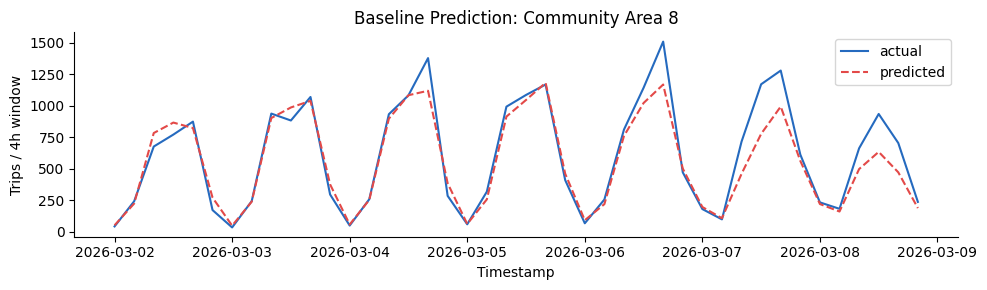

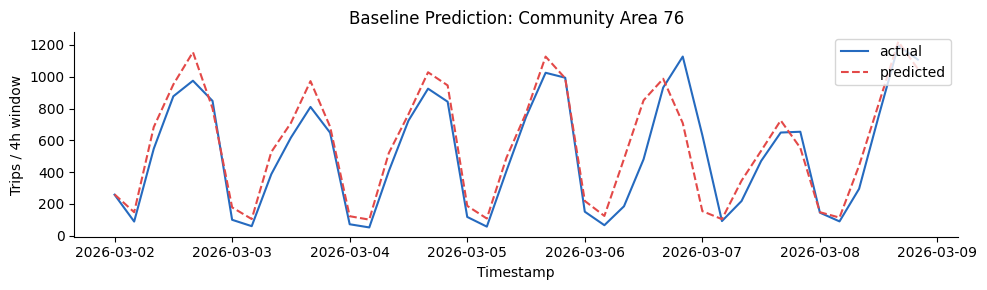

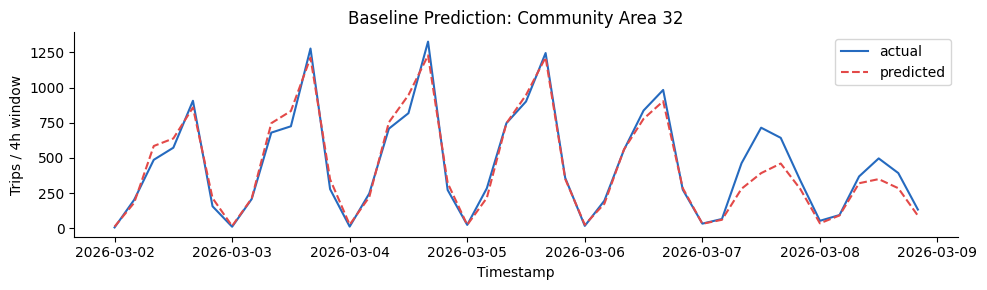

In [8]:
eval_mask = (test["timestamp"] >= EVAL_WEEK_START) & (test["timestamp"] < EVAL_WEEK_END)
test_plot = test[eval_mask].reset_index(drop=True)
test_plot_pred_base = baseline_y_pred[eval_mask.to_numpy()]

top_3_areas = test_plot.groupby("community_area")["count"].median().sort_values(ascending=False).head(3).index

for area in top_3_areas:
    mask = (test_plot["community_area"] == area).to_numpy()
    area_val = test_plot[mask]
    area_pred = test_plot_pred_base[mask]

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(area_val["timestamp"], area_val["count"], label="actual", color=SEQUENTIAL_BLUE)
    ax.plot(area_val["timestamp"], area_pred, label="predicted", color="#e34948", linestyle="--")
    ax.set_title(f"Baseline Prediction: Community Area {area}")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Trips / 4h window")
    ax.legend(loc="upper right")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

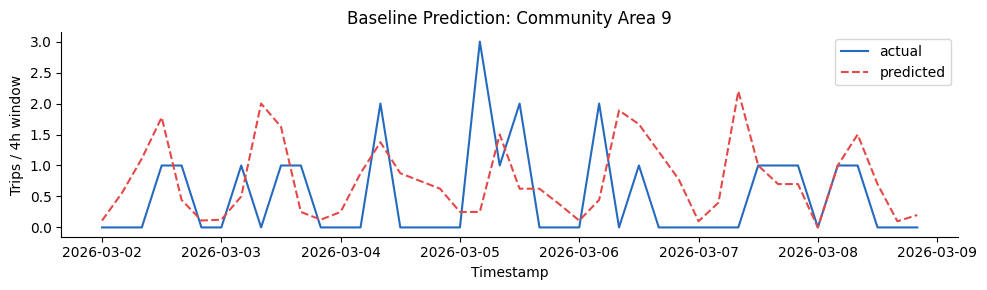

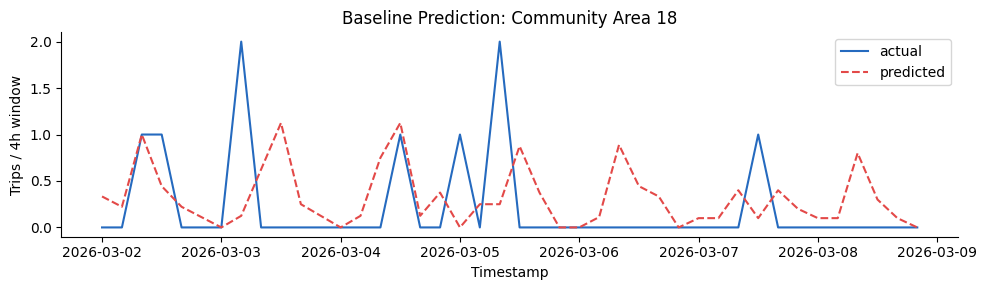

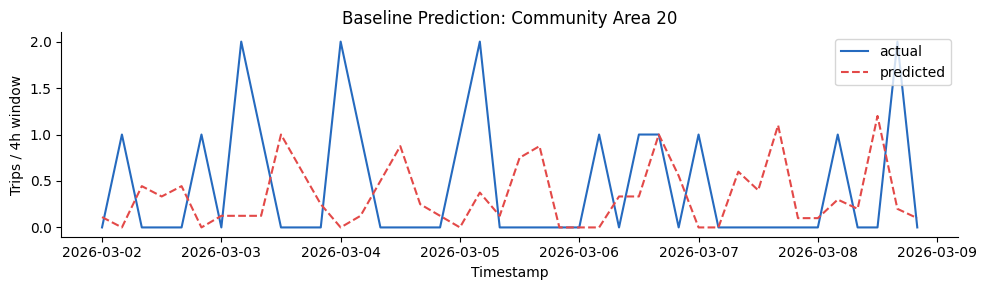

In [9]:
bottom_3_areas = test_plot.groupby("community_area")["count"].median().sort_values(ascending=True).head(3).index

for area in bottom_3_areas:
    mask = (test_plot["community_area"] == area).to_numpy()
    area_val = test_plot[mask]
    area_pred = test_plot_pred_base[mask]

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(area_val["timestamp"], area_val["count"], label="actual", color=SEQUENTIAL_BLUE)
    ax.plot(area_val["timestamp"], area_pred, label="predicted", color="#e34948", linestyle="--")
    ax.set_title(f"Baseline Prediction: Community Area {area}")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Trips / 4h window")
    ax.legend(loc="upper right")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

## 5. Shallow Neural Network -- Pooled, No Tuning

A single pooled feedforward network (one hidden layer, ReLU, `hidden_dim=64`) fit on all
training rows (all 77 areas), evaluated pooled and per area -- the NN counterpart of `03.01`
Section 5's plain `LinearSVR`.

**NN training machinery** (shared by Sections 5 and 6, and matching `03.06`): `train` is split
into `nn_fit`/`nn_es` by whole days (Validation Strategy). `fit_with_early_stopping` trains on
`nn_fit` and stops on the epoch that minimizes **count-space demand-weighted RMSE** on `nn_es`
(patience `NN_PATIENCE`, cap `NN_MAX_EPOCHS`) -- the same metric the headline results use, not
log-space MSE. That epoch count is then used by `fit_fixed_epochs` to **refit the model from
scratch on the full training set**, so the reported network isn't handicapped by the 80% fit
split. `TorchRegressor` wraps the trained network + its fitted `ColumnTransformer` behind a
`.predict(X)` method, so every evaluation helper from Section 3 works unchanged. The `nn_fit`-only
model is kept separately for the out-of-sample permutation importance below.


In [10]:
# Day-blocked early-stopping split (see Validation Strategy). At any given timestamp the 77
# community areas share the same weather/time features and differ only by their (static) area
# dummy, so a row-random split can place near-identical rows on both sides. Splitting whole
# DAYS keeps every window on one side -- the same fix 03.06 uses at tract level (and the reason
# the earlier random-split version of this notebook was inconsistent with it).
train_days = np.sort(train["timestamp"].dt.normalize().unique())
rng_split = np.random.default_rng(SEED)
n_es_days = int(round(0.2 * len(train_days)))
es_days = {pd.Timestamp(d) for d in rng_split.choice(train_days, size=n_es_days, replace=False)}
es_mask = train["timestamp"].dt.normalize().isin(es_days)

nn_fit = train[~es_mask].reset_index(drop=True)
nn_es  = train[es_mask].reset_index(drop=True)
print(f"nn_fit: {len(nn_fit):,} rows ({len(train_days) - n_es_days} train days)")
print(f"nn_es:  {len(nn_es):,} rows ({n_es_days} held-out days -- no timestamp shared with nn_fit)")

# Demand weights for the (day-blocked) ES slice -- the SAME weighting the headline weighted RMSE
# uses, so early stopping optimizes the reported count-space metric rather than log-space MSE.
es_unit_w = nn_es["community_area"].map(UNIT_WEIGHT).fillna(UNIT_WEIGHT.mean()).to_numpy()
es_true   = nn_es["count"].to_numpy(dtype=float)


def make_xy(df, cols, preprocess_obj, fit=False):
    """DataFrame -> (X, y) torch tensors with log1p-transformed y. `fit=True` fits
    `preprocess_obj` on this frame (only ever training splits, never nn_es/test)."""
    Xs = (preprocess_obj.fit_transform(df[cols]) if fit else preprocess_obj.transform(df[cols])).astype(np.float32)
    y = np.log1p(df["count"].to_numpy(dtype=np.float32))
    return torch.from_numpy(Xs), torch.from_numpy(y)


class TorchRegressor:
    """Wraps a trained torch model + its fitted ColumnTransformer behind a sklearn-style
    .predict(X), so predict_counts / the Section 3 evaluation helpers work unchanged."""
    def __init__(self, model, preprocess_obj):
        self.model, self.preprocess_obj = model, preprocess_obj

    def predict(self, X):
        Xs = self.preprocess_obj.transform(X).astype(np.float32)
        self.model.eval()
        with torch.no_grad():
            return self.model(torch.from_numpy(Xs).to(device)).cpu().numpy()


class ShallowNet(nn.Module):
    """One hidden layer + ReLU -- Section 5's model."""
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x))).squeeze(-1)


class DeepNet(nn.Module):
    """Two hidden layers + dropout (L2 via the optimizer's weight_decay) -- Section 6's model family."""
    def __init__(self, input_dim, hidden_dim1=128, hidden_dim2=64, dropout=0.2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)
        self.fc3 = nn.Linear(hidden_dim2, 1)

    def forward(self, x):
        x = self.dropout1(self.relu1(self.fc1(x)))
        x = self.dropout2(self.relu2(self.fc2(x)))
        return self.fc3(x).squeeze(-1)


class DeepNet5(nn.Module):
    """Five hidden layers + dropout after each -- Section 6's largest architecture candidate."""
    def __init__(self, input_dim, hidden_dims=(512, 256, 128, 64, 32), dropout=0.2):
        super().__init__()
        dims = [input_dim] + list(hidden_dims)
        self.layers = nn.ModuleList([nn.Linear(dims[i], dims[i + 1]) for i in range(len(dims) - 1)])
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(dropout)
        self.out = nn.Linear(hidden_dims[-1], 1)

    def forward(self, x):
        for layer in self.layers:
            x = self.drop(self.relu(layer(x)))
        return self.out(x).squeeze(-1)


def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * len(xb)
    return running / len(loader.dataset)


def eval_loss(model, X, y, criterion):
    model.eval()
    with torch.no_grad():
        return criterion(model(X.to(device)), y.to(device)).item()


def fit_with_early_stopping(model_ctor, X_fit_t, y_fit_t, X_es_t, y_es_t, lr, weight_decay, batch_size,
                             nn_es_df, preprocess_obj, unit_weights, es_true_counts, all_cols,
                             max_epochs=NN_MAX_EPOCHS, patience=NN_PATIENCE, label=""):
    """Stop on count-space demand-weighted RMSE on the (day-blocked) ES slice, not log-space
    MSE -- the same metric the headline weighted RMSE / skill use, and the same corrected
    procedure as 03.06. Used only to FIND the stopping epoch; the reported model is refit on
    full train via fit_fixed_epochs so the NN entry isn't handicapped by the 80% fit split
    (03.01's SVM fits on full train)."""
    torch.manual_seed(SEED)
    model = model_ctor().to(device)
    criterion = nn.MSELoss()  # still the training loss; just not the stopping signal
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loader = DataLoader(TensorDataset(X_fit_t, y_fit_t), batch_size=batch_size, shuffle=True,
                         generator=torch.Generator().manual_seed(SEED))

    best_loss, best_epoch, best_state, no_improve = float("inf"), 0, None, 0
    epoch = 0
    for epoch in range(1, max_epochs + 1):
        train_epoch(model, loader, criterion, optimizer)
        es_pred = predict_counts(TorchRegressor(model, preprocess_obj), nn_es_df[all_cols])
        es_loss = weighted_rmse(es_true_counts, es_pred, unit_weights)
        if es_loss < best_loss - 1e-5:
            best_loss, best_epoch, no_improve = es_loss, epoch, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= patience:
                break
    model.load_state_dict(best_state)
    print(f"{label}: stopped after {epoch} epochs (best epoch {best_epoch}, early-stop wRMSE {best_loss:.4f})")
    return model, best_epoch, best_loss


def fit_fixed_epochs(model_ctor, X_t, y_t, lr, weight_decay, batch_size, n_epochs, label=""):
    """Refit from scratch on ALL of train for n_epochs (the epoch count early stopping selected),
    no held-out slice -- so the final NN entry uses the full training set, matching 03.01's SVM."""
    torch.manual_seed(SEED)
    model = model_ctor().to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=True,
                         generator=torch.Generator().manual_seed(SEED))
    n = max(1, int(n_epochs))
    for _ in range(n):
        train_epoch(model, loader, criterion, optimizer)
    print(f"{label}: refit on full train for {n} epochs")
    return model


nn_fit: 270,270 rows (585 train days)
nn_es:  67,452 rows (146 held-out days -- no timestamp shared with nn_fit)


In [11]:
t0 = time.time()
# --- ES phase: scaler fit on nn_fit, find best_epoch on the day-blocked nn_es slice ---
prep_shallow_es = ColumnTransformer([
    ("scale", StandardScaler(), FEATURE_COLS),
    ("area_dummies", "passthrough", DUMMY_COLS),
])
X_fit_t, y_fit_t = make_xy(nn_fit, ALL_COLS, prep_shallow_es, fit=True)
X_es_t,  y_es_t  = make_xy(nn_es,  ALL_COLS, prep_shallow_es, fit=False)

shallow_ctor = lambda: ShallowNet(len(ALL_COLS), hidden_dim=64)
shallow_model_es, shallow_best_epoch, shallow_es_loss = fit_with_early_stopping(
    shallow_ctor, X_fit_t, y_fit_t, X_es_t, y_es_t, lr=1e-3, weight_decay=0.0, batch_size=512,
    nn_es_df=nn_es, preprocess_obj=prep_shallow_es, unit_weights=es_unit_w,
    es_true_counts=es_true, all_cols=ALL_COLS, label="Shallow NN (ES phase)",
)
# nn_fit-only model + its scaler -- kept for permutation importance (nn_es stays out-of-sample).
shallow_wrapper_es = TorchRegressor(shallow_model_es, prep_shallow_es)

# --- Final model: refit from scratch on ALL of train for best_epoch epochs, fresh scaler ---
prep_shallow = ColumnTransformer([
    ("scale", StandardScaler(), FEATURE_COLS),
    ("area_dummies", "passthrough", DUMMY_COLS),
])
X_train_s, y_train_s = make_xy(train, ALL_COLS, prep_shallow, fit=True)
shallow_model = fit_fixed_epochs(shallow_ctor, X_train_s, y_train_s, lr=1e-3, weight_decay=0.0,
                                 batch_size=512, n_epochs=shallow_best_epoch, label="Shallow NN (full-train refit)")
shallow_wrapper = TorchRegressor(shallow_model, prep_shallow)

y_pred_shallow = predict_counts(shallow_wrapper, test[ALL_COLS])
pm_shallow = metrics(y_true, y_pred_shallow)
res_shallow = per_area_results(test, y_pred_shallow)
res_shallow["skill"] = skill_vs_baseline(res_shallow)
res_shallow["relative_mae"] = relative_mae(res_shallow)
fit_time_shallow = time.time() - t0

print_pooled_results(f"Shallow NN ({fit_time_shallow:.0f}s)", pm_shallow, res_shallow,
                     weighted_rmse_value=weighted_rmse(y_true, y_pred_shallow, TEST_UNIT_WEIGHTS))


Shallow NN (ES phase): stopped after 37 epochs (best epoch 29, early-stop wRMSE 118.2445)
Shallow NN (full-train refit): refit on full train for 29 epochs
Shallow NN (324s)
  Pooled       : R2=0.925  MAE=9.70  RMSE=39.24  (sanity check only)
  Weighted RMSE: 144.96  (headline)
  Skill        : demand-weighted (headline)=-0.028  unweighted median=+0.097  median R2=0.324  (areas with negative skill: 14 of 77)


### 5.1 Feature Importance (Permutation Importance)

Unlike `LinearSVR`, a neural network has no per-feature coefficients to read off directly.
**Permutation importance** substitutes: shuffle one feature's values at a time (breaking its
relationship with the target while leaving everything else intact) and measure how much the
weighted RMSE degrades, averaged over 3 repeats. Measured on `nn_es`, which never received a
weight update -- `test` stays reserved for final metrics. Area dummies are skipped, same as
`03.01`'s coefficient plot (76 of them would swamp the chart; Section 6's outlook covers area
effects at the resolution comparison level instead).

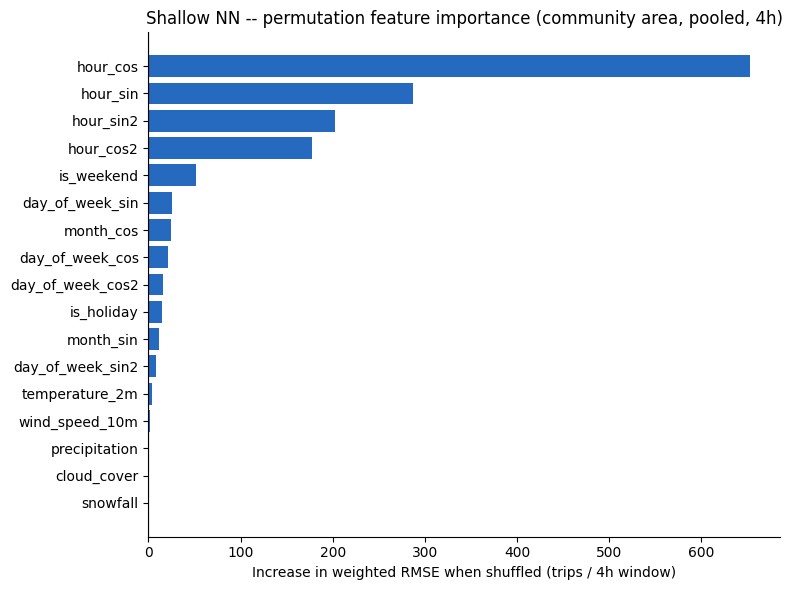

In [12]:
def permutation_importance_nn(model_wrapper, df, cols, n=17, n_repeats=3, seed=SEED):
    """Increase in weighted RMSE when a feature's values are shuffled (averaged over n_repeats)."""
    rng = np.random.default_rng(seed)
    base_pred = predict_counts(model_wrapper, df[cols])
    unit_w = df["community_area"].map(UNIT_WEIGHT).fillna(UNIT_WEIGHT.mean()).to_numpy()
    base_score = weighted_rmse(df["count"].to_numpy(dtype=float), base_pred, unit_w)

    rows = []
    for col in cols:
        if col in DUMMY_COLS:
            continue
        deltas = []
        for _ in range(n_repeats):
            df_shuf = df.copy()
            df_shuf[col] = rng.permutation(df_shuf[col].to_numpy())
            pred = predict_counts(model_wrapper, df_shuf[cols])
            deltas.append(weighted_rmse(df_shuf["count"].to_numpy(dtype=float), pred, unit_w) - base_score)
        rows.append({"feature": col, "importance": float(np.mean(deltas))})

    return pd.DataFrame(rows).sort_values("importance", ascending=False).head(n)


# nn_fit-only model on the out-of-sample nn_es slice -> honest permutation importances.
top_imp_shallow = permutation_importance_nn(shallow_wrapper_es, nn_es, ALL_COLS)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_imp_shallow["feature"][::-1], top_imp_shallow["importance"][::-1], color=SEQUENTIAL_BLUE)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel(f"Increase in weighted RMSE when shuffled (trips / {FREQ} window)")
ax.set_title(f"Shallow NN -- permutation feature importance (community area, pooled, {FREQ})")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


## 6. Hyperparameter Tuning -- Architecture Search (One-Factor-at-a-Time + Combine Winners)

The NN counterpart of `03.01` Sections 6-7 (kernel comparison + `GridSearchCV`). The tuning
surface here is network depth/width, regularization strength (dropout, weight decay), learning
rate, and batch size, explored as a **one-factor-at-a-time (OFAT) screen**: every candidate is a
single reference configuration (`DEEP_REF`) with exactly **one knob turned**, so a candidate
beating the reference attributes the gain to that one knob. Each candidate gets one early-stopped
run on the shared day-blocked
`nn_fit`/`nn_es` split, stopped on count-space demand-weighted RMSE, and is ranked by
**demand-weighted skill vs. the profile baseline on `test`** -- the same skill-score decision
`03.01` uses to choose its reported entry (early-stopping loss only decides *when to stop* a given
candidate).

**Section 6.1 then does the "combine the winners" step**: it measures each knob's skill delta vs.
the reference, keeps every knob that *improved* skill (both regularization knobs independently,
plus the single best-improving capacity setting, since a network has only one width/depth), and
**retrains one model with all the kept knobs turned on together**. That combined model is added to
the candidate pool, and the final Deep NN entry is whichever config -- reference, a single-knob
variant, or the combined-winners config -- has the best demand-weighted skill. The selected config
is written to `results/best_deep_config.json` so `03.05` (1h) and `03.06` (tract) can reuse it
without re-running this search.


In [13]:
# Reference configuration -- the Deep NN with NOTHING turned on (no regularization, the same
# 128/64 two-layer width as a sensible default). Every grid candidate below is this reference
# with exactly ONE knob turned, so a candidate beating the reference isolates that one knob's
# effect (one-factor-at-a-time screen). Section 6.1 then retrains a single model with ALL the
# knobs that helped turned on together.
DEEP_REF = {"arch": "deep2", "hidden_dim1": 128, "hidden_dim2": 64, "dropout": 0.0, "weight_decay": 0.0, "lr": 1e-3, "batch_size": 512}

# Two independent regularization knobs (each can be on or off independently of the others)...
REG_KNOBS = {
    "dropout=0.2":       {"dropout": 0.2},
    "weight_decay=1e-4": {"weight_decay": 1e-4},
}
# ...and four MUTUALLY EXCLUSIVE capacity settings (a network has one width/depth, so at most one
# of these can be part of the combined config -- the best-improving one wins in 6.1).
CAP_KNOBS = {
    "width 64/32":   {"arch": "deep2", "hidden_dim1": 64,  "hidden_dim2": 32},
    "width 256/128": {"arch": "deep2", "hidden_dim1": 256, "hidden_dim2": 128},
    "width 512/256": {"arch": "deep2", "hidden_dim1": 512, "hidden_dim2": 256},
    "depth deep5":   {"arch": "deep5", "hidden_dims": (512, 256, 128, 64, 32)},
}

LR_KNOBS = {
    "lr=1e-4": {"lr": 1e-4},
    "lr=3e-4": {"lr": 3e-4},
    "lr=3e-3": {"lr": 3e-3},
    "lr=1e-2": {"lr": 1e-2}
}

BATCH_KNOBS = {
    "batch_size=128":  {"batch_size": 128},
    "batch_size=256":  {"batch_size": 256},
    "batch_size=1024": {"batch_size": 1024},
    "batch_size=2048": {"batch_size": 2048},
}


def build_deep_ctor(cfg):
    """Model constructor from a config dict, dispatching on arch (deep2 vs deep5)."""
    if cfg.get("arch", "deep2") == "deep2":
        return lambda: DeepNet(len(ALL_COLS), hidden_dim1=cfg["hidden_dim1"],
                               hidden_dim2=cfg["hidden_dim2"], dropout=cfg.get("dropout", 0.0))
    return lambda: DeepNet5(len(ALL_COLS), hidden_dims=tuple(cfg["hidden_dims"]), dropout=cfg.get("dropout", 0.0))


# The OFAT grid: reference first, then reference-with-one-knob for every knob above.
deep_param_grid = [("reference", DEEP_REF)]
for _name, _delta in {**REG_KNOBS, **CAP_KNOBS, **LR_KNOBS, **BATCH_KNOBS}.items():
    deep_param_grid.append((_name, {**DEEP_REF, **_delta}))

t0 = time.time()
# One shared ES-phase scaler (fit on nn_fit) -- every candidate is trained on nn_fit and stopped
# on the day-blocked nn_es slice by count-space weighted RMSE, so the candidates are comparable.
# Only the final selected config (Section 6.1) is refit on full train.
prep_deep_es = ColumnTransformer([
    ("scale", StandardScaler(), FEATURE_COLS),
    ("area_dummies", "passthrough", DUMMY_COLS),
])
X_fit_deep, y_fit_deep = make_xy(nn_fit, ALL_COLS, prep_deep_es, fit=True)
X_es_deep,  y_es_deep  = make_xy(nn_es,  ALL_COLS, prep_deep_es, fit=False)


def train_candidate(cfg, label):
    model, best_epoch, es_loss = fit_with_early_stopping(
        build_deep_ctor(cfg), X_fit_deep, y_fit_deep, X_es_deep, y_es_deep,
        lr=cfg["lr"], weight_decay=cfg["weight_decay"], batch_size=cfg["batch_size"],
        nn_es_df=nn_es, preprocess_obj=prep_deep_es, unit_weights=es_unit_w,
        es_true_counts=es_true, all_cols=ALL_COLS, label=label,
    )
    wrapper = TorchRegressor(model, prep_deep_es)
    res_c = per_area_results(test, predict_counts(wrapper, test[ALL_COLS]))
    res_c["skill"] = skill_vs_baseline(res_c)
    return {"model": model, "best_epoch": best_epoch, "es_loss": es_loss,
            "demand_weighted_skill": weighted_skill_vs_baseline(res_c)}


deep_search_rows = []
for name, cfg in deep_param_grid:
    r = train_candidate(cfg, f"[grid] {name}")
    deep_search_rows.append({"knob": name, **{k: cfg.get(k) for k in
                             ["arch", "hidden_dim1", "hidden_dim2", "hidden_dims", "dropout", "weight_decay", "lr", "batch_size"]},
                             "best_epoch": r["best_epoch"], "es_loss": r["es_loss"],
                             "demand_weighted_skill": r["demand_weighted_skill"], "_model": r["model"], "_cfg": cfg})
fit_time_deep_search = time.time() - t0

deep_search_df = pd.DataFrame(deep_search_rows)
print("\nOFAT grid -- each row is the reference with one knob turned (ES-phase models, ranked by skill):")
print(deep_search_df.drop(columns=["_model", "_cfg"]).sort_values("demand_weighted_skill", ascending=False).to_string(index=False))


[grid] reference: stopped after 37 epochs (best epoch 29, early-stop wRMSE 115.3385)
[grid] dropout=0.2: stopped after 37 epochs (best epoch 29, early-stop wRMSE 122.1035)
[grid] weight_decay=1e-4: stopped after 19 epochs (best epoch 11, early-stop wRMSE 120.8815)
[grid] width 64/32: stopped after 32 epochs (best epoch 24, early-stop wRMSE 115.6325)
[grid] width 256/128: stopped after 23 epochs (best epoch 15, early-stop wRMSE 120.8751)
[grid] width 512/256: stopped after 27 epochs (best epoch 19, early-stop wRMSE 115.7555)
[grid] depth deep5: stopped after 27 epochs (best epoch 19, early-stop wRMSE 119.9283)
[grid] lr=1e-4: stopped after 70 epochs (best epoch 62, early-stop wRMSE 118.3599)
[grid] lr=3e-4: stopped after 34 epochs (best epoch 26, early-stop wRMSE 116.0381)
[grid] lr=3e-3: stopped after 28 epochs (best epoch 20, early-stop wRMSE 115.1074)
[grid] lr=1e-2: stopped after 28 epochs (best epoch 20, early-stop wRMSE 122.9977)
[grid] batch_size=128: stopped after 34 epochs (bes

In [14]:
# --- 6.1 Which knobs helped? Keep the winners, retrain one model with all of them turned on. ---
by_knob = deep_search_df.set_index("knob")
ref_skill = by_knob.loc["reference", "demand_weighted_skill"]
print(f"Reference Deep NN demand-weighted skill: {ref_skill:+.4f}")
print("\nPer-knob effect (skill delta vs. reference; a knob 'helped' if delta > 0):")

improving_reg, improving_cap, improving_lr, improving_batch = {}, {}, {}, {}
for name in REG_KNOBS:
    delta = by_knob.loc[name, "demand_weighted_skill"] - ref_skill
    verb = "HELPED" if delta > 0 else "hurt/neutral"
    print(f"  {name:20s} {delta:+.4f}  ({verb})")
    if delta > 0:
        improving_reg[name] = REG_KNOBS[name]
for name in CAP_KNOBS:
    delta = by_knob.loc[name, "demand_weighted_skill"] - ref_skill
    verb = "HELPED" if delta > 0 else "hurt/neutral"
    print(f"  {name:20s} {delta:+.4f}  ({verb})")
    if delta > 0:
        improving_cap[name] = by_knob.loc[name, "demand_weighted_skill"]
for name in LR_KNOBS:
    delta = by_knob.loc[name, "demand_weighted_skill"] - ref_skill
    verb = "HELPED" if delta > 0 else "hurt/neutral"
    print(f"  {name:20s} {delta:+.4f}  ({verb})")
    if delta > 0:
        improving_lr[name] = by_knob.loc[name, "demand_weighted_skill"]
for name in BATCH_KNOBS:
    delta = by_knob.loc[name, "demand_weighted_skill"] - ref_skill
    verb = "HELPED" if delta > 0 else "hurt/neutral"
    print(f"  {name:20s} {delta:+.4f}  ({verb})")
    if delta > 0:
        improving_batch[name] = by_knob.loc[name, "demand_weighted_skill"]

# Capacity settings are mutually exclusive -> keep only the single best-improving one.
best_cap = max(improving_cap, key=improving_cap.get) if improving_cap else None

# Build the combined-winners config: reference + every improving regularization knob + the best
# improving capacity knob (if any). If nothing beat the reference, the combined config IS the
# reference.
combined_cfg = dict(DEEP_REF)
for delta in improving_reg.values():
    combined_cfg.update(delta)
if best_cap is not None:
    combined_cfg.update(CAP_KNOBS[best_cap])
if improving_lr:
    combined_cfg.update(LR_KNOBS[max(improving_lr, key=improving_lr.get)])
if improving_batch:
    combined_cfg.update(BATCH_KNOBS[max(improving_batch, key=improving_batch.get)])

kept = (list(improving_reg) + ([best_cap] if best_cap else [])
        + (list(improving_lr) if improving_lr else []) + (list(improving_batch) if improving_batch else []))
print(f"\nKnobs kept (improved skill): {kept if kept else 'none -- reference wins'}")
print(f"Combined-winners config: { {k: combined_cfg.get(k) for k in ['arch','hidden_dim1','hidden_dim2','hidden_dims','dropout','weight_decay','lr','batch_size'] if combined_cfg.get(k) is not None} }")

# Retrain the combined config with the same ES + full-train-refit procedure, add it to the pool.
combined = train_candidate(combined_cfg, "[combined winners]")
print(f"Combined-winners demand-weighted skill: {combined['demand_weighted_skill']:+.4f}  "
      f"(reference {ref_skill:+.4f})")

# --- Final selection: best demand-weighted skill over the whole pool (grid + combined) ---
pool = [(row["knob"], row["_cfg"], row["best_epoch"], row["demand_weighted_skill"])
        for _, row in deep_search_df.iterrows()]
pool.append(("combined winners", combined_cfg, combined["best_epoch"], combined["demand_weighted_skill"]))
best_name, best_cfg, best_epoch_sel, best_skill = max(pool, key=lambda t: t[3])
print(f"\nSelected Deep NN config: '{best_name}'  (demand-weighted skill {best_skill:+.4f})")

# --- Refit the selected config from scratch on ALL of train_tract-equivalent (full train) ---
prep_deep = ColumnTransformer([
    ("scale", StandardScaler(), FEATURE_COLS),
    ("area_dummies", "passthrough", DUMMY_COLS),
])
X_train_d, y_train_d = make_xy(train, ALL_COLS, prep_deep, fit=True)
deep_model = fit_fixed_epochs(build_deep_ctor(best_cfg), X_train_d, y_train_d, lr=best_cfg["lr"],
                              weight_decay=best_cfg["weight_decay"], batch_size=best_cfg["batch_size"],
                              n_epochs=best_epoch_sel, label="Deep NN (selected, full-train refit)")
deep_wrapper = TorchRegressor(deep_model, prep_deep)

y_pred_deep = predict_counts(deep_wrapper, test[ALL_COLS])
pm_deep = metrics(y_true, y_pred_deep)
res_deep = per_area_results(test, y_pred_deep)
res_deep["skill"] = skill_vs_baseline(res_deep)
res_deep["relative_mae"] = relative_mae(res_deep)
fit_time_deep = fit_time_deep_search

print_pooled_results(f"Deep NN, tuned + combined-winners, selected by skill "
                     f"({fit_time_deep:.0f}s search)", pm_deep, res_deep,
                     weighted_rmse_value=weighted_rmse(y_true, y_pred_deep, TEST_UNIT_WEIGHTS))

# --- Export the selected config so 03.05 (1h) and 03.06 (tract) reuse it instead of re-running
# the grid search -- this is the only notebook that runs the full architecture search. ---
BEST_DEEP_CONFIG = {"arch": best_cfg.get("arch", "deep2"),
                    "dropout": float(best_cfg.get("dropout", 0.0)),
                    "weight_decay": float(best_cfg.get("weight_decay", 0.0)),
                    "lr": float(best_cfg.get("lr", 1e-3)),
                    "batch_size": int(best_cfg.get("batch_size", 512))}
if BEST_DEEP_CONFIG["arch"] == "deep2":
    BEST_DEEP_CONFIG["hidden_dim1"] = int(best_cfg["hidden_dim1"])
    BEST_DEEP_CONFIG["hidden_dim2"] = int(best_cfg["hidden_dim2"])
else:
    BEST_DEEP_CONFIG["hidden_dims"] = [int(x) for x in best_cfg["hidden_dims"]]
BEST_DEEP_CONFIG["selected_knob"] = best_name
BEST_DEEP_CONFIG["source_notebook"] = "03.04_prediction_nn_CA_4h.ipynb"
BEST_DEEP_CONFIG["selected_at"] = pd.Timestamp.now().isoformat(timespec="seconds")

CONFIG_DIR = pathlib.Path("../../results")
CONFIG_DIR.mkdir(parents=True, exist_ok=True)
CONFIG_PATH = CONFIG_DIR / "best_deep_config.json"
CONFIG_PATH.write_text(json.dumps(BEST_DEEP_CONFIG, indent=2))
print(f"\nWrote selected deep config to {CONFIG_PATH} (reused by 03.05 and 03.06):")
print(json.dumps(BEST_DEEP_CONFIG, indent=2))


Reference Deep NN demand-weighted skill: +0.0130

Per-knob effect (skill delta vs. reference; a knob 'helped' if delta > 0):
  dropout=0.2          -0.0484  (hurt/neutral)
  weight_decay=1e-4    +0.0212  (HELPED)
  width 64/32          -0.0369  (hurt/neutral)
  width 256/128        -0.0747  (hurt/neutral)
  width 512/256        -0.0617  (hurt/neutral)
  depth deep5          -0.0747  (hurt/neutral)
  lr=1e-4              -0.0190  (hurt/neutral)
  lr=3e-4              -0.0071  (hurt/neutral)
  lr=3e-3              -0.0378  (hurt/neutral)
  lr=1e-2              -0.0233  (hurt/neutral)
  batch_size=128       +0.0053  (HELPED)
  batch_size=256       -0.0292  (hurt/neutral)
  batch_size=1024      -0.0119  (hurt/neutral)
  batch_size=2048      -0.0376  (hurt/neutral)

Knobs kept (improved skill): ['weight_decay=1e-4', 'batch_size=128']
Combined-winners config: {'arch': 'deep2', 'hidden_dim1': 128, 'hidden_dim2': 64, 'dropout': 0.0, 'weight_decay': 0.0001, 'lr': 0.001, 'batch_size': 128}
[comb

## 7. Results -- Model Comparison

Three candidates: profile baseline, Shallow NN (Section 5), Deep NN (tuned, Section 6) -- the
NN counterpart of `03.01` Section 8's five-way comparison (no demand-weighted-refit or
demand-tiered variants here: `sample_weight`-style reweighting and per-tier pooling are SVM-side
workarounds for `LinearSVR`'s single shared linear coefficient per feature; a neural network's
hidden layer can already combine area identity with time/weather non-linearly without either
trick -- see Section 8 for whether that capacity actually pays off here).

Two headline metrics: demand-weighted skill (relative to baseline, comparable across
resolutions and against 03.01's SVM entry) and weighted RMSE (absolute trips/window).
Unweighted median skill and relative MAE are supporting detail.
           Model  Demand-weighted skill  Median skill  Weighted RMSE  Median relative MAE  Pooled R2  Median R2/area
Profile baseline                  0.000         0.000        139.015                0.423      0.933           0.208
      Shallow NN                 -0.028         0.097        144.956                0.384      0.925           0.324
 Deep NN (tuned)                 -0.027         0.071        145.927                0.396      0.927           0.276


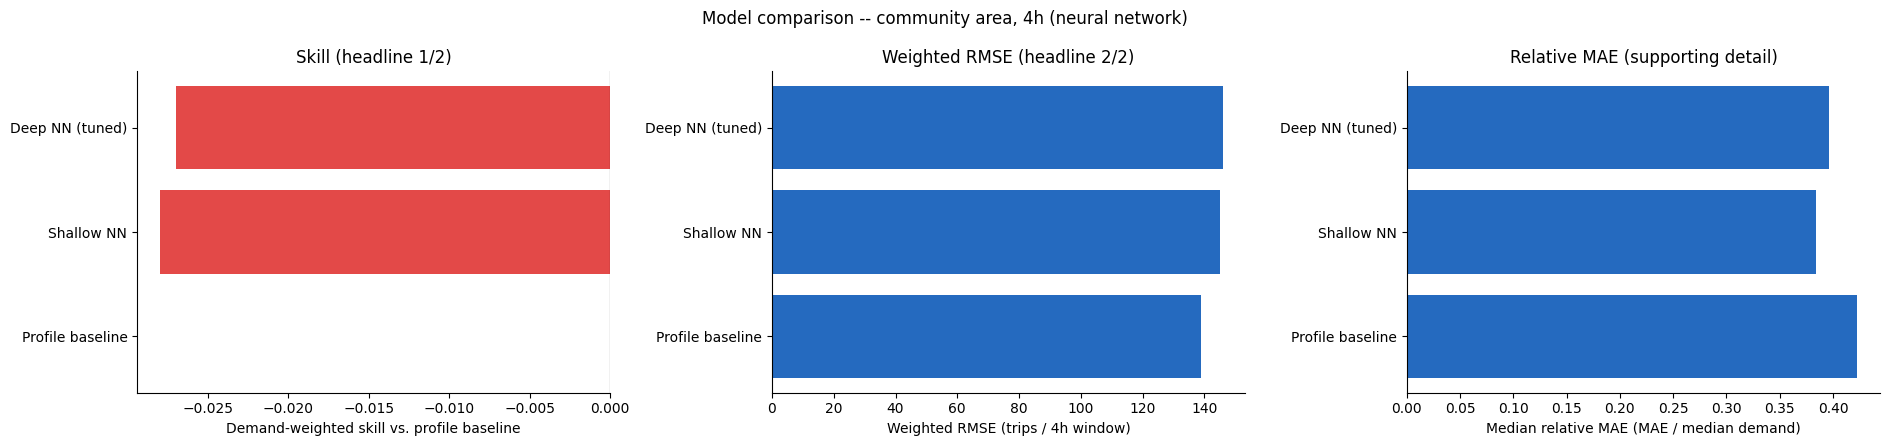

In [15]:
comparison_df = pd.DataFrame([
    {"Model": "Profile baseline", "Demand-weighted skill": 0.000, "Median skill": 0.000,
     "Weighted RMSE": weighted_rmse(y_true, baseline_y_pred, TEST_UNIT_WEIGHTS),
     "Median relative MAE": baseline_results["relative_mae"].median(),
     "Pooled R2": pm_baseline["r2"], "Median R2/area": baseline_results["r2"].median()},
    {"Model": "Shallow NN",
     "Demand-weighted skill": weighted_skill_vs_baseline(res_shallow), "Median skill": res_shallow["skill"].median(),
     "Weighted RMSE": weighted_rmse(y_true, y_pred_shallow, TEST_UNIT_WEIGHTS),
     "Median relative MAE": res_shallow["relative_mae"].median(),
     "Pooled R2": pm_shallow["r2"], "Median R2/area": res_shallow["r2"].median()},
    {"Model": "Deep NN (tuned)",
     "Demand-weighted skill": weighted_skill_vs_baseline(res_deep), "Median skill": res_deep["skill"].median(),
     "Weighted RMSE": weighted_rmse(y_true, y_pred_deep, TEST_UNIT_WEIGHTS),
     "Median relative MAE": res_deep["relative_mae"].median(),
     "Pooled R2": pm_deep["r2"], "Median R2/area": res_deep["r2"].median()},
]).round(3)
print("Two headline metrics: demand-weighted skill (relative to baseline, comparable across")
print("resolutions and against 03.01's SVM entry) and weighted RMSE (absolute trips/window).")
print("Unweighted median skill and relative MAE are supporting detail.")
print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(19, 4.5))
chart_df = comparison_df.set_index("Model")["Demand-weighted skill"]
colors_cmp = [SEQUENTIAL_BLUE if v >= 0 else "#e34948" for v in chart_df]
axes[0].barh(chart_df.index, chart_df.to_numpy(), color=colors_cmp)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("Demand-weighted skill vs. profile baseline")
axes[0].set_title("Skill (headline 1/2)")
axes[0].spines[["top", "right"]].set_visible(False)

wrmse_df = comparison_df.set_index("Model")["Weighted RMSE"]
axes[1].barh(wrmse_df.index, wrmse_df.to_numpy(), color=SEQUENTIAL_BLUE)
axes[1].set_xlabel("Weighted RMSE (trips / 4h window)")
axes[1].set_title("Weighted RMSE (headline 2/2)")
axes[1].spines[["top", "right"]].set_visible(False)

rmae_df = comparison_df.set_index("Model")["Median relative MAE"]
axes[2].barh(rmae_df.index, rmae_df.to_numpy(), color=SEQUENTIAL_BLUE)
axes[2].set_xlabel("Median relative MAE (MAE / median demand)")
axes[2].set_title("Relative MAE (supporting detail)")
axes[2].spines[["top", "right"]].set_visible(False)
plt.suptitle("Model comparison -- community area, 4h (neural network)")
plt.tight_layout()
plt.show()

### 7.0b Are the Differences Real? Day-Block Bootstrap

The comparison table above reports one skill number per model, but the test period is a single
five-month window -- so how much of the Shallow-vs-Deep gap is signal? Same method as `03.06`'s
tract-level check: resample the test period by whole days with replacement (`N_BOOT` times,
preserving the within-day cross-area correlation) and recompute demand-weighted skill each time.
If the 95% CI for the Deep-minus-Shallow difference straddles zero, the two networks are
statistically indistinguishable here and the simpler one should be preferred.


Shallow NN   demand-weighted skill: -0.026  95% CI [-0.056, +0.005]
Deep NN      demand-weighted skill: -0.027  95% CI [-0.050, -0.002]

Deep - Shallow: -0.001  95% CI [-0.024, +0.023]  (P(Deep>Shallow)=0.49)
CI for the difference straddling 0 => the two NNs are statistically indistinguishable here.


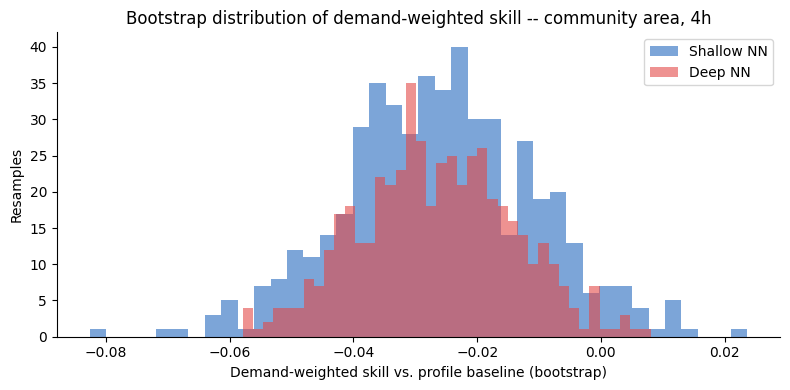

In [16]:
# Day-block bootstrap of demand-weighted skill (same method as 03.06's tract-level 5.7.0b):
# resample whole test days with replacement -- preserving the within-day cross-area correlation
# -- and recompute the headline metric each time, so the comparison table's skill gaps get a
# confidence interval instead of a single point estimate.
test_day  = test["timestamp"].dt.normalize().to_numpy()
uniq_days = np.unique(test_day)
area_arr  = test["community_area"].to_numpy()
count_arr = test["count"].to_numpy(dtype=float)
day_to_rows = {d: np.where(test_day == d)[0] for d in uniq_days}


def _weighted_skill_on_idx(idx, y_pred):
    a  = area_arr[idx]
    em = np.abs(count_arr[idx] - np.asarray(y_pred)[idx])
    eb = np.abs(count_arr[idx] - baseline_y_pred[idx])
    g  = pd.DataFrame({"a": a, "em": em, "eb": eb}).groupby("a").mean()
    g  = g[g["eb"] > 0]                       # skip areas with a degenerate (zero-MAE) baseline
    skill = 1 - g["em"] / g["eb"]
    w = AREA_MEDIAN_DEMAND.reindex(g.index).to_numpy()
    return float(np.average(skill.to_numpy(), weights=w)) if w.sum() > 0 else np.nan


def block_bootstrap(y_pred, n_boot=N_BOOT, seed=SEED):
    rng = np.random.default_rng(seed)
    out = np.empty(n_boot)
    for b in range(n_boot):
        days = rng.choice(uniq_days, size=len(uniq_days), replace=True)
        idx = np.concatenate([day_to_rows[d] for d in days])
        out[b] = _weighted_skill_on_idx(idx, y_pred)
    return out


boot_shallow = block_bootstrap(y_pred_shallow)
boot_deep    = block_bootstrap(y_pred_deep)
diff = boot_deep - boot_shallow


def _ci(a):
    a = a[~np.isnan(a)]
    return float(np.mean(a)), float(np.percentile(a, 2.5)), float(np.percentile(a, 97.5))


for name, b in [("Shallow NN", boot_shallow), ("Deep NN", boot_deep)]:
    m, lo, hi = _ci(b)
    print(f"{name:12s} demand-weighted skill: {m:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]")
dm, dlo, dhi = _ci(diff)
p_better = float(np.mean(diff[~np.isnan(diff)] > 0))
print(f"\nDeep - Shallow: {dm:+.3f}  95% CI [{dlo:+.3f}, {dhi:+.3f}]  (P(Deep>Shallow)={p_better:.2f})")
print("CI for the difference straddling 0 => the two NNs are statistically indistinguishable here.")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot_shallow, bins=40, alpha=0.6, color=SEQUENTIAL_BLUE, label="Shallow NN")
ax.hist(boot_deep,    bins=40, alpha=0.6, color="#e34948",       label="Deep NN")
ax.set_xlabel("Demand-weighted skill vs. profile baseline (bootstrap)")
ax.set_ylabel("Resamples")
ax.set_title(f"Bootstrap distribution of demand-weighted skill -- community area, {FREQ}")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


### 7.0 Actual vs. Predicted (Test Set)

Same three models as the comparison table above, same test set, same axes -- a tighter cluster
along the dashed diagonal means better predictions. Plotted on `log1p` scale (a 5,000-point
random sample), same convention as `03.01` Section 8.0.

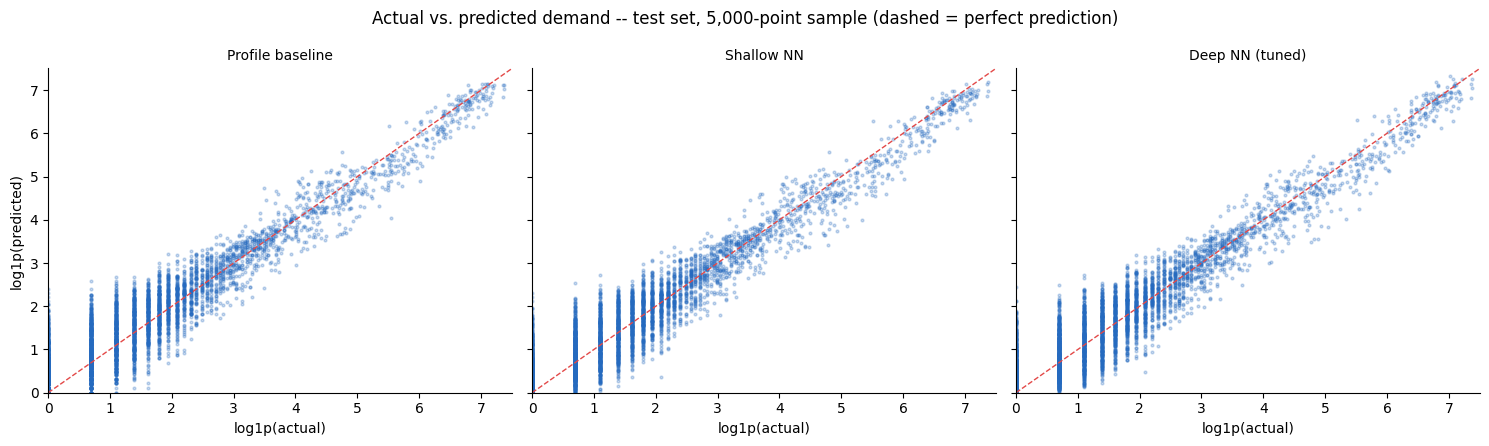

In [17]:
models_to_plot = [
    ("Profile baseline", baseline_y_pred),
    ("Shallow NN", y_pred_shallow),
    ("Deep NN (tuned)", y_pred_deep),
]

rng_viz = np.random.RandomState(0)
sample_n = min(5000, len(y_true))
sample_idx = rng_viz.choice(len(y_true), size=sample_n, replace=False)
log_true = np.log1p(y_true)
lims = [0, log_true.max()]

fig, axes = plt.subplots(1, len(models_to_plot), figsize=(15, 4.5), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, models_to_plot):
    log_pred = np.log1p(y_pred)
    ax.scatter(log_true[sample_idx], log_pred[sample_idx], s=4, alpha=0.25, color=SEQUENTIAL_BLUE)
    ax.plot(lims, lims, color="#e34948", linewidth=1, linestyle="--")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("log1p(actual)")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("log1p(predicted)")
plt.suptitle(f"Actual vs. predicted demand -- test set, {sample_n:,}-point sample "
             f"(dashed = perfect prediction)")
plt.tight_layout()
plt.show()

### 7.1 Per-Area Performance

**Two complementary scores**, both comparable across areas of very different demand: **skill**
(relative to the profile baseline) and **relative MAE** (`mae / (median_demand + 1)`, absolute,
no baseline). Shown for whichever of Shallow/Deep NN scores higher on demand-weighted skill
(printed below) -- the NN entry carried forward, same role `03.01`'s unweighted `LinearSVR`
plays there.

NN entry carried forward for the per-area breakdown: Deep NN (tuned)


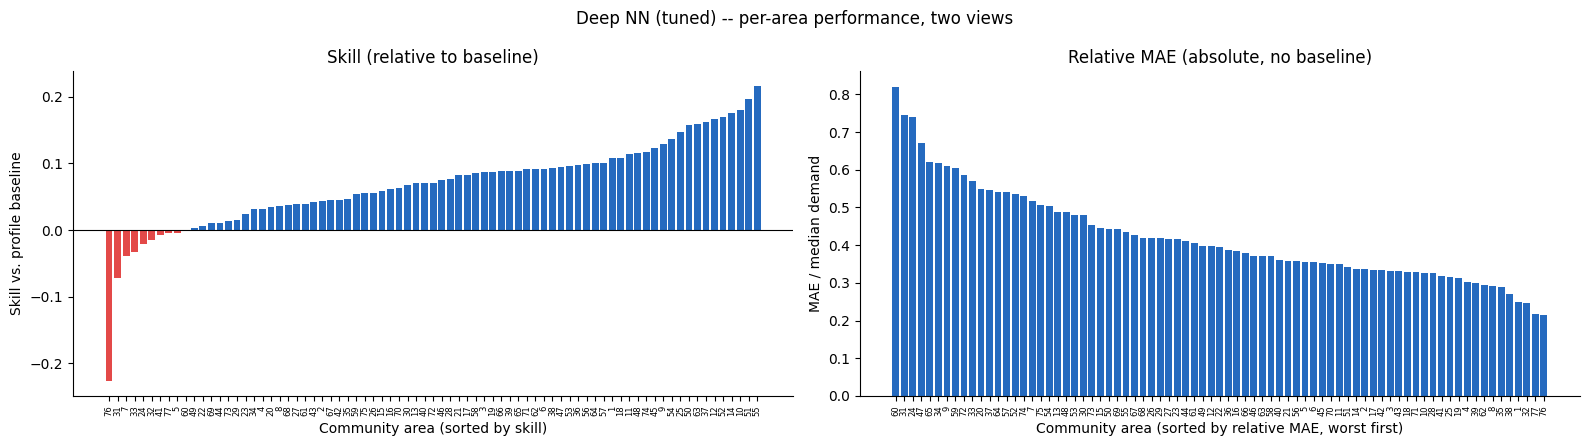

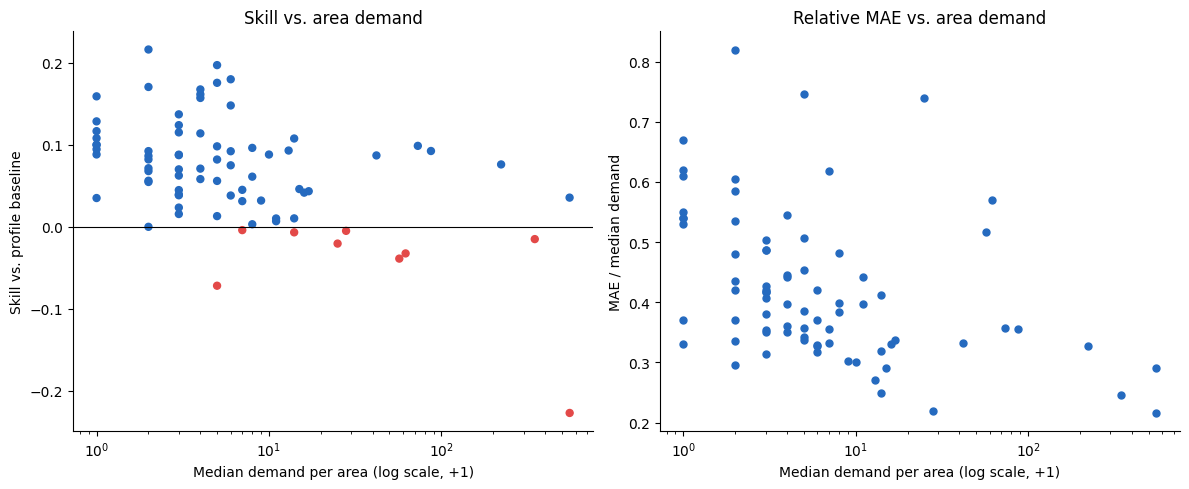

In [18]:
nn_entry_name = "Deep NN (tuned)" if weighted_skill_vs_baseline(res_deep) >= weighted_skill_vs_baseline(res_shallow) else "Shallow NN"
res_nn = res_deep if nn_entry_name == "Deep NN (tuned)" else res_shallow
y_pred_nn = y_pred_deep if nn_entry_name == "Deep NN (tuned)" else y_pred_shallow
print(f"NN entry carried forward for the per-area breakdown: {nn_entry_name}")

res_nn_by_skill = res_nn.merge(
    AREA_MEDIAN_DEMAND, left_on="community_area", right_index=True
).sort_values("skill").reset_index(drop=True)
colors_skill = [SEQUENTIAL_BLUE if v >= 0 else "#e34948" for v in res_nn_by_skill["skill"]]

res_nn_by_rmae = res_nn.merge(
    AREA_MEDIAN_DEMAND, left_on="community_area", right_index=True
).sort_values("relative_mae", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
axes[0].bar(range(len(res_nn_by_skill)), res_nn_by_skill["skill"], color=colors_skill, width=0.8)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xticks(range(len(res_nn_by_skill)))
axes[0].set_xticklabels(res_nn_by_skill["community_area"], rotation=90, fontsize=6)
axes[0].set_xlabel("Community area (sorted by skill)")
axes[0].set_ylabel("Skill vs. profile baseline")
axes[0].set_title("Skill (relative to baseline)")

axes[1].bar(range(len(res_nn_by_rmae)), res_nn_by_rmae["relative_mae"], color=SEQUENTIAL_BLUE, width=0.8)
axes[1].set_xticks(range(len(res_nn_by_rmae)))
axes[1].set_xticklabels(res_nn_by_rmae["community_area"], rotation=90, fontsize=6)
axes[1].set_xlabel("Community area (sorted by relative MAE, worst first)")
axes[1].set_ylabel("MAE / median demand")
axes[1].set_title("Relative MAE (absolute, no baseline)")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.suptitle(f"{nn_entry_name} -- per-area performance, two views")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(res_nn_by_skill["median_demand"] + 1, res_nn_by_skill["skill"], color=colors_skill, s=25)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xscale("log")
axes[0].set_xlabel("Median demand per area (log scale, +1)")
axes[0].set_ylabel("Skill vs. profile baseline")
axes[0].set_title("Skill vs. area demand")

axes[1].scatter(res_nn_by_rmae["median_demand"] + 1, res_nn_by_rmae["relative_mae"], color=SEQUENTIAL_BLUE, s=25)
axes[1].set_xscale("log")
axes[1].set_xlabel("Median demand per area (log scale, +1)")
axes[1].set_ylabel("MAE / median demand")
axes[1].set_title("Relative MAE vs. area demand")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Per-area skill map for the NN entry (plain pooled fit, full data) -- no areas excluded, same
convention as `03.01` Section 8.1.

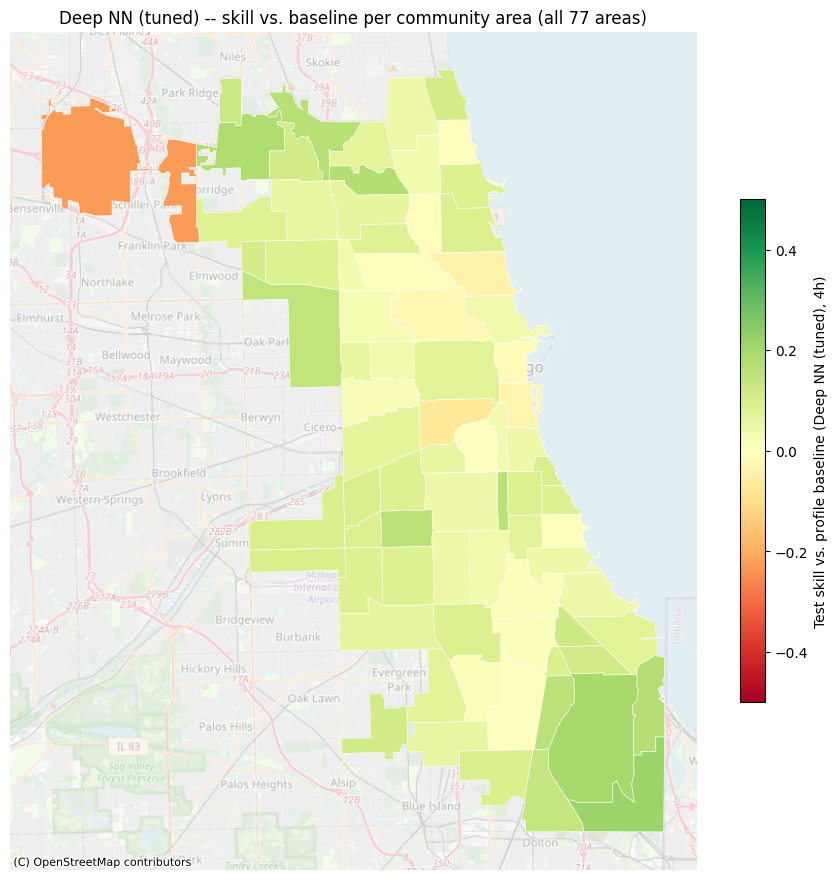

In [19]:
community_areas_gdf = gpd.read_file(COMMUNITY_AREAS_PATH)
community_areas_gdf["area_numbe"] = community_areas_gdf["area_numbe"].astype(int)

gdf_skill = community_areas_gdf.merge(
    res_nn[["community_area", "skill"]],
    left_on="area_numbe", right_on="community_area", how="left",
).to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(9, 9))
gdf_skill.plot(ax=ax, column="skill", cmap="RdYlGn", vmin=-0.5, vmax=0.5, legend=True,
               legend_kwds={"label": f"Test skill vs. profile baseline ({nn_entry_name}, 4h)", "shrink": 0.6},
               edgecolor="white", linewidth=0.4)
ctx.add_basemap(ax, crs=gdf_skill.crs, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.35)
ax.set_title(f"{nn_entry_name} -- skill vs. baseline per community area (all 77 areas)")
ax.axis("off")
plt.tight_layout()
plt.show()

### 7.2 Top 3 / Bottom 3 Areas -- All Models

Actual vs. all three models for the top-3 and bottom-3 areas (by median demand), same eval week
used for the baseline-only view in Section 4.1.

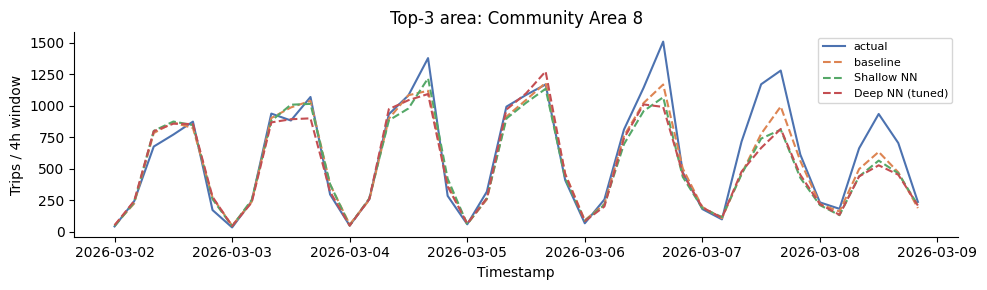

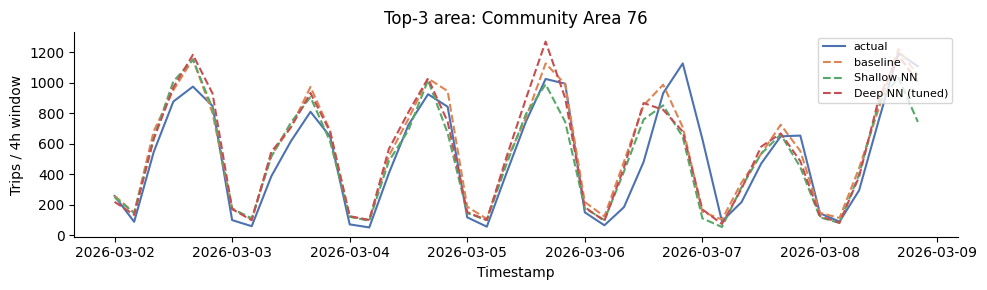

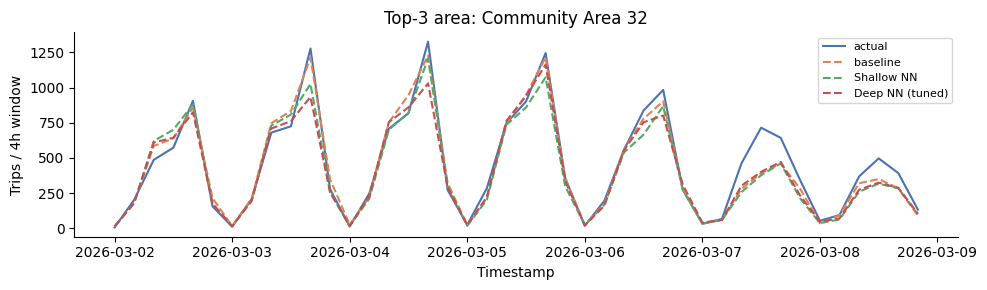

In [20]:
test_plot_pred_shallow = y_pred_shallow[eval_mask.to_numpy()]
test_plot_pred_deep    = y_pred_deep[eval_mask.to_numpy()]

models_to_plot_ts = [
    ("baseline", test_plot_pred_base),
    ("Shallow NN", test_plot_pred_shallow),
    ("Deep NN (tuned)", test_plot_pred_deep),
]


def plot_area_all_models(areas, title_prefix):
    for area in areas:
        mask = (test_plot["community_area"] == area).to_numpy()
        area_val = test_plot[mask]

        fig, ax = plt.subplots(figsize=(10, 3))
        ax.plot(area_val["timestamp"], area_val["count"], label="actual", color=CATEGORICAL_COLORS[0])
        for i, (name, y_pred) in enumerate(models_to_plot_ts):
            ax.plot(area_val["timestamp"], y_pred[mask], label=name,
                    color=CATEGORICAL_COLORS[i + 1], linestyle="--")
        ax.set_title(f"{title_prefix}: Community Area {area}")
        ax.set_xlabel("Timestamp")
        ax.set_ylabel("Trips / 4h window")
        ax.legend(loc="upper right", fontsize=8)
        ax.spines[["top", "right"]].set_visible(False)
        plt.tight_layout()
        plt.show()


plot_area_all_models(top_3_areas, "Top-3 area")

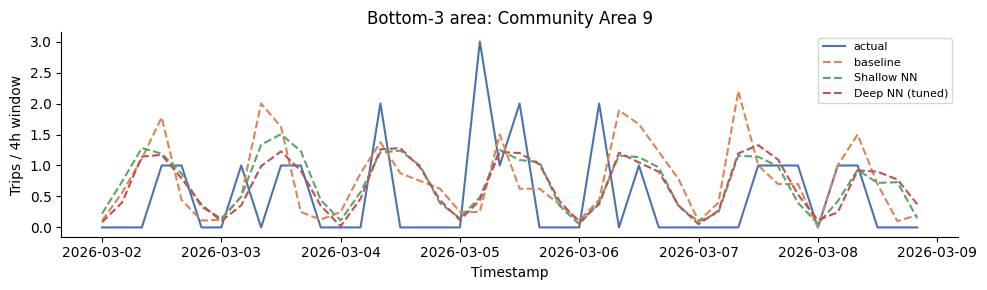

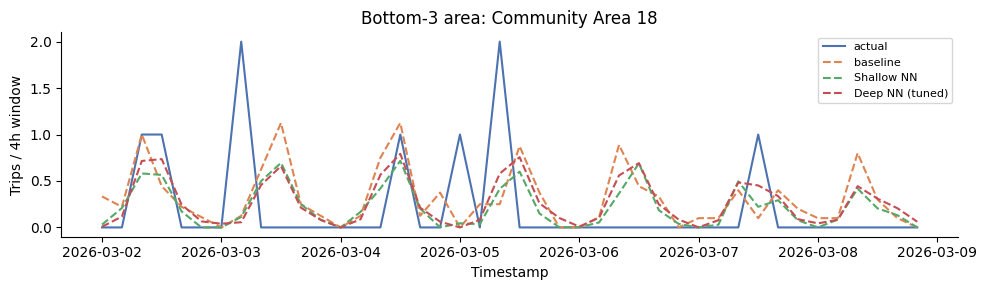

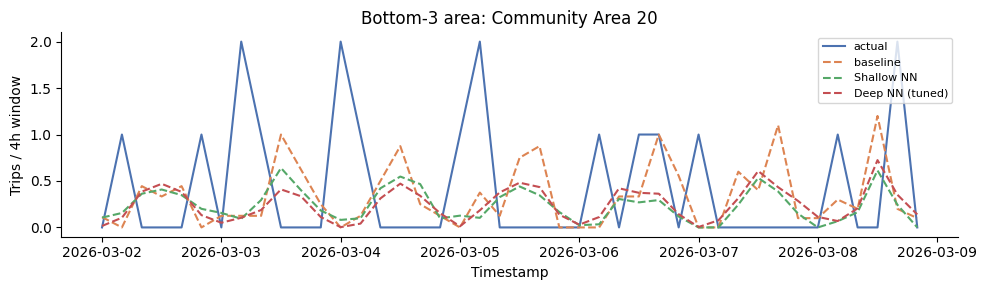

In [21]:
plot_area_all_models(bottom_3_areas, "Bottom-3 area")

## 8. Export Results

Append this run's three models to the shared results CSVs -- the same `model_results_summary.csv`
and `model_results_by_area.csv` `03.01`/`03.02`/`03.03` write to, so both model families and all
resolutions end up directly comparable in one place. Reruns overwrite this notebook's own prior
rows (matched on model + notebook + resolution) rather than duplicating them.

In [22]:
RESULTS_DIR = pathlib.Path("../../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_CSV = RESULTS_DIR / "model_results_summary.csv"
DETAIL_CSV  = RESULTS_DIR / "model_results_by_area.csv"
NOTEBOOK_NAME = "03.04_prediction_nn_CA_4h.ipynb"


def upsert_csv(df_new, path, key_cols):
    """Append df_new to the CSV at `path`, replacing any existing rows with the same key_cols
    (so reruns update in place instead of duplicating) -- creates the file if it doesn't exist."""
    if path.exists():
        df_old = pd.read_csv(path)
        old_keys = df_old[key_cols].apply(tuple, axis=1)
        new_keys = set(df_new[key_cols].apply(tuple, axis=1))
        df_out = pd.concat([df_old[~old_keys.isin(new_keys)], df_new], ignore_index=True)
    else:
        df_out = df_new
    df_out.to_csv(path, index=False)
    return df_out


run_timestamp = pd.Timestamp.now().isoformat(timespec="seconds")

nn_models = [
    ("Profile baseline", pm_baseline, baseline_results, y_true, baseline_y_pred, TEST_UNIT_WEIGHTS,
     fit_time_base, 0.0, 0.0, len(ALL_AREAS)),
    ("Shallow NN", pm_shallow, res_shallow, y_true, y_pred_shallow, TEST_UNIT_WEIGHTS,
     fit_time_shallow, weighted_skill_vs_baseline(res_shallow), res_shallow["skill"].median(), len(ALL_AREAS)),
    ("Deep NN (tuned)", pm_deep, res_deep, y_true, y_pred_deep, TEST_UNIT_WEIGHTS,
     fit_time_deep, weighted_skill_vs_baseline(res_deep), res_deep["skill"].median(), len(ALL_AREAS)),
]

summary_rows, detail_rows = [], []
for model_name, pm, res_df, y_true_m, y_pred_m, weights_m, fit_time, skill_w, skill_med, n_units in nn_models:
    summary_rows.append({
        "model_name": model_name,
        "notebook": NOTEBOOK_NAME,
        "spatial_resolution": "community_area",
        "temporal_resolution": FREQ,
        "n_units": n_units,
        "train_start": DATA_START.date().isoformat(),
        "train_end": (TRAIN_END - pd.Timedelta(days=1)).date().isoformat(),
        "test_start": TRAIN_END.date().isoformat(),
        "test_end": (DATA_END_EXCL - pd.Timedelta(days=1)).date().isoformat(),
        "rmse": pm["rmse"],
        "mae": pm["mae"],
        "r2": pm["r2"],
        "weighted_rmse": weighted_rmse(y_true_m, y_pred_m, weights_m),
        "skill_demand_weighted": round(float(skill_w), 4),
        "skill_median": round(float(skill_med), 4),
        "fit_time_s": round(fit_time, 2),
        "last_run_at": run_timestamp,
    })
    for _, row in res_df.iterrows():
        detail_rows.append({
            "model_name": model_name,
            "notebook": NOTEBOOK_NAME,
            "spatial_resolution": "community_area",
            "temporal_resolution": FREQ,
            "unit_id": int(row["community_area"]),
            "median_demand": AREA_MEDIAN_DEMAND.get(row["community_area"]),
            "rmse": row["rmse"],
            "mae": row["mae"],
            "r2": row["r2"],
            "skill": row.get("skill", 0.0),
            "relative_mae": row["relative_mae"],
            "last_run_at": run_timestamp,
        })

summary_df = pd.DataFrame(summary_rows)
detail_df = pd.DataFrame(detail_rows)

upsert_csv(summary_df, SUMMARY_CSV,
           key_cols=["model_name", "notebook", "spatial_resolution", "temporal_resolution"])
upsert_csv(detail_df, DETAIL_CSV,
           key_cols=["model_name", "notebook", "spatial_resolution", "temporal_resolution", "unit_id"])

print(f"Wrote {len(summary_df)} rows to {SUMMARY_CSV}")
print(f"Wrote {len(detail_df)} rows to {DETAIL_CSV}")
summary_df

Wrote 3 rows to ..\..\results\model_results_summary.csv
Wrote 231 rows to ..\..\results\model_results_by_area.csv


,model_name,notebook,spatial_resolution,temporal_resolution,n_units,train_start,train_end,test_start,test_end,rmse,mae,r2,weighted_rmse,skill_demand_weighted,skill_median,fit_time_s,last_run_at
0,Profile baseline,03.04_prediction_nn_CA_4h.ipynb,community_area,4h,77,2024-01-01,2025-12-31,2026-01-01,2026-05-31,37.31,9.53,0.9326,139.015067,0.0000,0.0000,0.77,2026-07-21T20:32:00
1,Shallow NN,03.04_prediction_nn_CA_4h.ipynb,community_area,4h,77,2024-01-01,2025-12-31,2026-01-01,2026-05-31,39.24,9.70,0.9254,144.955851,-0.0276,0.0970,324.49,2026-07-21T20:32:00
2,Deep NN (tuned),03.04_prediction_nn_CA_4h.ipynb,community_area,4h,77,2024-01-01,2025-12-31,2026-01-01,2026-05-31,38.88,9.50,0.9268,145.927293,-0.0274,0.0714,2332.73,2026-07-21T20:32:00


## 9. Shortfalls & Honest Limitations

- **One-hot area dummies, not learned embeddings**: the input feature set is identical to
  `03.01` on purpose (direct comparability), but a neural network is exactly the model family
  that could learn a dense area embedding instead of 76 independent dummy weights -- not done
  here, so this notebook doesn't yet exploit an advantage specific to NNs.
- **Single day-blocked early-stopping split, not a repeated CV**: `03.01`'s `KFold(3)` averages
  over three folds; the NN training loop here uses a single held-out slice (whole days, to avoid
  cross-area leakage), both because retraining from scratch per fold is expensive per candidate
  and because early stopping already provides an implicit regularization signal a single slice
  can give. The day-block bootstrap in Section 7.0b puts a confidence interval on the final
  skill gap even though the split itself isn't repeated.
- **Tuning surface covered is still small**: Section 6 screens one factor at a time around one
  reference configuration (depth/width/dropout/weight-decay/learning-rate/batch-size) and then
  combines the winners; optimizer choice (always Adam) is fixed throughout.
- **Fixed effects assume every unit is seen in training**, same caveat as `03.01`; no
  rolling-origin backtest yet.
- See Section 7 for whether either model actually beats the profile baseline, and where -- the
  same high-demand-area pattern `03.01` documents for `LinearSVR` may or may not carry over.


## 10. Outlook

- **1-hour resolution**: `03.05` (same 77 areas, ~4x the rows -- a scaling stress test, same
  role as `03.02` on the SVM side).
- **Census tract resolution**: `03.06` (179 in-scope tracts, GMM-hotspot distance features
  instead of raw tract dummies, same scope as `03.03`).
- Both reuse this notebook's panel-building/evaluation helpers directly.
- Results feed the NN section of the report, read directly against `03.01`'s SVM entry via the
  shared `results/model_results_summary.csv`.